# Sensitivity charts

## Mappings from dashboard json exports to chart labels and number formatting

In [12]:
import json
from pathlib import Path

# Per-metric display format (string templates)
format_val = {
  # Envelope (spread)
  "median_W":           "{:.1f}",     # absolute width (units of variable)
  "p90_W":              "{:.1f}",
  "RW_med":             "{:.0%}",     # relative width (median)
  "RW_high":            "{:.0%}",     # on event days
  "RW_low":             "{:.0%}",
  "Peak_ratio":         "{:.2f}×",

  # Central shift (displacement)
  "CS_abs":             "{:.1f}",     # absolute shift
  "CS_rel":             "{:.1%}",     # relative shift
  "Signed_C_shift":     "{:+.1%}",    # signed relative shift

  # Coverage
  "Coverage_frac":      "{:.0%}",
  "coverage100":        "{:.0%}",
  "Outside_upper":      "{:.0%}",
  "Outside_lower":      "{:.0%}",

  # Event contrast
  "Event_contrast":     "{:+.0%}",    # RW_high − RW_low (relative units)
  "Event_ratio":        "{:.2f}×",

  # Duration-curve signature
  "RA_5":               "{:.0%}",
  "RA_50":              "{:.0%}",
  "RA_95":              "{:.0%}",

  # Optional shift detail (from your table)
  "delta_mean":         "{:+.0f}",
  "median_delta":       "{:+.0f}",
  "median_delta_pct":   "{:+.0%}",
  "delta_min":          "{:+.0f}",
  "delta_p50":          "{:+.0f}",
  "delta_p90":          "{:+.0f}",
  "delta_max":          "{:+.0f}",
  "delta_event_pairs_mean": "{:+.0f}",
  "delta_non_event_pairs_mean": "{:+.0f}",
  "normalized_mean_delta": "{:+.0%}",

  # Bias metrics
  "PBIAS%": "{:+.0f}%",
  "Bias(obs-pred)": "{:+.0f}",

  # Alias/legacy keys (if used)
  "relative_width":      "{:.0%}",
  "relative_width_high": "{:.0%}",
  "relative_width_low":  "{:.0%}",
  "relative_width_event": "{:.0%}",
  "relative_width_nonevent": "{:.0%}",
  "relative_width_event_contrast": "{:+.0%}",
  "event_ratio": "{:.2f}×",
}

# Single source of truth for label selection.
#
# Each key is the technical metric name expected in the exported stats JSON.
# `label` is what you pass in semantic_labels.
# Add `path` only when that metric name appears in multiple places in the export JSON.
# Example: "path": ("overlay_comparison", "__baseline__", "relative_width")
semantic_label_map = {
  # Width & spread
  "median_W": {"label": "Model raw width median (W)"},
  "p90_W": {"label": "Model raw width p90 (W)"},
  "RW_med": {"path": ("overlay_comparison", "__baseline__", "relative_width"), "label": "Model relative width (min-max / median)"},
  "RW_high": {"label": "Relative width (event days)"},
  "RW_low": {"label": "Relative width (non-event days)"},

  # Shift & coverage
  "Coverage_frac": {"label": "Coverage fraction (overlay inside envelope)"},
  "delta_mean": {"path": ("overlay_comparison", "BASE", "delta_mean"), "label": "Mean shift (baseline - overlay)"},
  "median_delta": {"path": ("overlay_comparison", "BASE", "median_delta"), "label": "Shift median"},
  "delta_min": {"label": "Shift in min (baseline - overlay)"},
  "delta_p50": {"label": "Shift in p50 (baseline - overlay)"},
  "delta_p90": {"label": "Shift in p90 (baseline - overlay)"},
  "delta_max": {"label": "Shift in max (baseline - overlay)"},
  "delta_event_pairs_mean": {"path": ("overlay_comparison", "BASE", "delta_event_pairs_mean"), "label": "Shift events (mean)"},
  "delta_non_event_pairs_mean": {"path": ("overlay_comparison", "BASE", "delta_non_event_pairs_mean"), "label": "Shift non-events (mean)"},
  "normalized_mean_delta": {"label": "Normalized mean shift (delta / baseline mean)"},
  "coverage100": {"path": ("same_day", "coverage100"), "label": "Min/Max Coverage (observations inside envelope)"}, 


  # BIAS
  "PBIAS%": {"path": ("same_day", "PBIAS%"), "label": "PBIAS (%) - sum(observed - simulated) / sum(observed) * 100"},
  "Bias(obs-pred)": {"path": ("same_day", "Bias(obs-pred)"), "label": "Bias (absolute) - sum(observed - simulated)"},


  # Event contrast (if used)
  "relative_width_event_contrast": {"label": "Event contrast (high / low)"},
  "event_ratio": {"label": "Event ratio (event / non-event)"},
  "relative_width_high": {"label": "Relative width high decile"},
  "relative_width_low": {"label": "Relative width low decile"},

}




### helper functions to convert data according to mappings

In [13]:
# Backwards-compatible flat view if you still want a technical-name -> label lookup elsewhere.
semantic_label = {
    technical_name: spec["label"]
    for technical_name, spec in semantic_label_map.items()
}

def _is_scalar_metric_value(value):
    """Return True for JSON scalar metric values that can be stored in the example dict."""
    return isinstance(value, (int, float)) and not isinstance(value, bool)


def _normalise_export_spec(export_spec):
    """
    Accept one export item in one of two forms:
      - {"path": ..., "scenario": ..., "variable": ...}
      - (path, scenario, variable)
    
    Variable can be omitted from the dict if the JSON file contains
    dashboard_state.variable, but scenario must always be supplied because it is
    not part of the current export payload.
    """
    if isinstance(export_spec, dict):
        path = export_spec.get("path")
        scenario = export_spec.get("scenario")
        variable = export_spec.get("variable")
    elif isinstance(export_spec, (tuple, list)) and len(export_spec) == 3:
        path, scenario, variable = export_spec
    else:
        raise TypeError(
            "Each export spec must be either a dict with keys 'path', 'scenario', 'variable' "
            "or a 3-item tuple/list of (path, scenario, variable)."
        )

    if not path:
        raise ValueError(f"Invalid export spec {export_spec!r}: missing file path.")
    if not scenario:
        raise ValueError(
            f"Invalid export spec {export_spec!r}: missing scenario. "
            "Scenario is not stored in the current JSON export, so it must be provided explicitly."
        )

    return Path(path), str(scenario), variable


def _load_stat_export(export_spec, *, verbose=True):
    """Load one JSON export file and return its payload plus resolved identifiers."""
    path, scenario, variable = _normalise_export_spec(export_spec)
    if verbose:
        print(f"Loading stats export: {path}")

    if not path.exists():
        raise FileNotFoundError(f"Stats export file does not exist: {path}")

    with path.open("r", encoding="utf-8") as handle:
        payload = json.load(handle)

    if not isinstance(payload, dict):
        raise ValueError(f"Stats export {path} does not contain a top-level JSON object.")

    dashboard_state = payload.get("metadata", {}).get("dashboard_state") or payload.get("dashboard_state") or {}
    if variable is None:
        variable = dashboard_state.get("variable")

    if not variable:
        raise ValueError(
            f"Could not determine variable for {path}. "
            "Provide it explicitly in the export spec or ensure the payload has dashboard_state.variable."
        )

    stats = payload.get("stats")
    if not isinstance(stats, dict):
        raise ValueError(f"Stats export {path} is missing a 'stats' dictionary.")

    if verbose:
        print(f"  scenario={scenario}, variable={variable}")
    return {
        "path": path,
        "scenario": str(scenario),
        "variable": str(variable),
        "payload": payload,
        "stats": stats,
    }


def _normalise_semantic_entry(technical_name, entry):
    """Normalise one semantic_label_map entry to {'label': ..., 'path': ...}."""
    if isinstance(entry, str):
        spec = {"label": entry, "path": None}
    elif isinstance(entry, dict):
        label = entry.get("label")
        if not label or not isinstance(label, str):
            raise ValueError(
                f"semantic_label_map[{technical_name!r}] must define a string 'label'."
            )
        path = entry.get("path")
        if path is not None:
            if not isinstance(path, (tuple, list)) or not path or not all(isinstance(part, str) for part in path):
                raise ValueError(
                    f"semantic_label_map[{technical_name!r}]['path'] must be a non-empty tuple/list of strings."
                )
            path = tuple(path)
        spec = {"label": label, "path": path}
    else:
        raise TypeError(
            f"semantic_label_map[{technical_name!r}] must be either a label string or a dict with 'label' and optional 'path'."
        )

    return spec


def _normalise_semantic_label_map(semantic_label_map):
    """Return a validated semantic_label_map with uniform dict entries."""
    normalised = {}
    reverse_semantic_label = {}
    duplicate_labels = {}

    for technical_name, entry in semantic_label_map.items():
        spec = _normalise_semantic_entry(technical_name, entry)
        label = spec["label"]
        if label in reverse_semantic_label and reverse_semantic_label[label] != technical_name:
            duplicate_labels.setdefault(label, set()).update([reverse_semantic_label[label], technical_name])
        reverse_semantic_label[label] = technical_name
        normalised[technical_name] = spec

    if duplicate_labels:
        raise ValueError(
            "semantic_label_map contains duplicate labels mapped to different technical names: "
            f"{ {label: sorted(names) for label, names in duplicate_labels.items()} }"
        )

    return normalised


def _find_metric_matches(node, technical_name, path=()):
    """
    Recursively search the exported stats dictionary for a technical metric key.

    Returns a list of (path_tuple, value) matches so ambiguous metrics can be
    reported clearly instead of silently choosing the wrong number.
    """
    matches = []

    if isinstance(node, dict):
        for key, value in node.items():
            next_path = path + (str(key),)
            if key == technical_name and _is_scalar_metric_value(value):
                matches.append((next_path, value))
            matches.extend(_find_metric_matches(value, technical_name, next_path))

    elif isinstance(node, list):
        for index, value in enumerate(node):
            matches.extend(_find_metric_matches(value, technical_name, path + (str(index),)))

    return matches


def _extract_metric_value(stats_dict, technical_name, explicit_path=None, *, verbose=True):
    """Extract one metric value from the exported stats dictionary."""
    if explicit_path is not None:
        explicit_path = tuple(explicit_path)
        current = stats_dict
        for part in explicit_path:
            if not isinstance(current, dict) or part not in current:
                raise KeyError(
                    f"Explicit path {explicit_path!r} for '{technical_name}' does not exist in the stats export."
                )
            current = current[part]
        if current is None:
            if verbose:
                print(f"    explicit path {explicit_path} for '{technical_name}' is null, treating as 0")
            return 0
        if not _is_scalar_metric_value(current):
            raise ValueError(
                f"Explicit path {explicit_path!r} for '{technical_name}' does not resolve to a numeric scalar."
            )
        if verbose:
            print(f"    using semantic_label_map path {explicit_path} -> {current}")
        return current

    matches = _find_metric_matches(stats_dict, technical_name)
    if not matches:
        raise KeyError(
            f"Metric '{technical_name}' was not found anywhere in the stats export. "
            "If it is nested under an ambiguous branch, add a 'path' entry in semantic_label_map for it."
        )
    if len(matches) > 1:
        pretty_paths = [" -> ".join(path) for path, _ in matches]
        raise ValueError(
            f"Metric '{technical_name}' matched more than one location in the stats export: {pretty_paths}. "
            "Add a 'path' entry to semantic_label_map for this metric."
        )

    metric_path, metric_value = matches[0]
    if verbose:
        print(f"    found {technical_name} at {' -> '.join(metric_path)} = {metric_value}")
    return metric_value


def _format_metric_value(value, fmt, technical_name):
    """Render one numeric value with the metric format string."""
    try:
        return fmt.format(value)
    except Exception as exc:
        raise ValueError(
            f"Could not format value {value!r} for metric '{technical_name}' with format {fmt!r}."
        ) from exc


def _build_requested_metric_specs(semantic_labels, semantic_label_map, format_map):
    """Resolve requested labels to technical names, formats, and optional paths."""
    reverse_semantic_label = {
        spec["label"]: technical_name
        for technical_name, spec in semantic_label_map.items()
    }

    requested_specs = []
    for requested_label in semantic_labels:
        if requested_label in reverse_semantic_label:
            technical_name = reverse_semantic_label[requested_label]
            output_label = requested_label
        elif requested_label in semantic_label_map:
            technical_name = requested_label
            output_label = semantic_label_map[requested_label]["label"]
        else:
            available = sorted(reverse_semantic_label.keys())
            raise KeyError(
                f"Unknown semantic label or technical name: {requested_label!r}. "
                f"Available semantic labels include: {available}"
            )

        if technical_name not in format_map:
            raise KeyError(
                f"No format string found in format_val for technical metric '{technical_name}'. "
                "Add it to format_val before building the metrics dictionary."
            )

        requested_specs.append(
            {
                "technical_name": technical_name,
                "output_label": output_label,
                "format": format_map[technical_name],
                "path": semantic_label_map[technical_name].get("path"),
            }
        )

    return requested_specs


def build_metrics_dict_from_stat_exports(
    export_specs,
    semantic_labels,
    *,
    semantic_label_map=None,
    format_map=None,
    scenario_order=None,
    variable_order=None,
    include_technical_names=False,
    format_mode="metadata",
    verbose=True,
):
    """
    Build a dict with the same structure as the earlier manual 'metrics' blocks from a
    list of dashboard JSON exports.

    Parameters
    ----------
    export_specs : list
        One item per scenario-variable combination. Recommended form:
            {"path": <json_path>, "scenario": "WASTE", "variable": "TP"}
        A tuple/list of (path, scenario, variable) also works.

    semantic_labels : list[str]
        Labels you want in the output dictionary, using the labels defined in
        semantic_label_map, for example:
            ["Median width", "Coverage", "Mean Δ"]
        Technical keys are also accepted directly.

    semantic_label_map : dict, optional
        Mapping of technical metric names to config dicts with:
            - 'label': display label used in semantic_labels
            - 'path' : optional explicit path inside the exported stats dict
        A plain string value is also accepted as shorthand for {'label': <string>}.

    format_map : dict, optional
        Mapping of technical metric names to format strings. If a technical name
        has no format entry, the function raises a helpful error.

    scenario_order / variable_order : list, optional
        If omitted, the function uses the order in which scenarios and variables
        appear in export_specs.

    include_technical_names : bool, default False
        If True, each output metric also gets a '__technical_name' field.

    format_mode : {'metadata', 'values'}, default 'metadata'
        'metadata' keeps numeric values and adds '__format'.
        'values' applies the format string to each extracted value and omits '__format'.

    verbose : bool, default True
        Print progress information while reading files and extracting metrics.

    Returns
    -------
    dict
        A dictionary shaped like:
            {
                "metrics": {
                    "Median width": {
                        "__format": "{:.1f}",
                        "WASTE": {"TP": 12.8, "TN": 17.6},
                        ...
                    },
                    ...
                }
            }
    """
    if semantic_label_map is None:
        semantic_label_map = globals()["semantic_label_map"]
    semantic_label_map = _normalise_semantic_label_map(semantic_label_map)

    if format_map is None:
        format_map = format_val

    valid_format_modes = {"metadata", "values"}
    if format_mode not in valid_format_modes:
        raise ValueError(
            f"format_mode must be one of {sorted(valid_format_modes)}, got {format_mode!r}."
        )

    if not export_specs:
        raise ValueError("export_specs is empty. Provide one export spec per scenario-variable combination.")
    if not semantic_labels:
        raise ValueError("semantic_labels is empty. Provide at least one label to extract.")

    loaded_exports = []
    seen_scenarios = []
    seen_variables = []

    if verbose:
        print(f"Preparing to read {len(export_specs)} stats export files...")

    for export_spec in export_specs:
        loaded = _load_stat_export(export_spec, verbose=verbose)
        loaded_exports.append(loaded)
        if loaded["scenario"] not in seen_scenarios:
            seen_scenarios.append(loaded["scenario"])
        if loaded["variable"] not in seen_variables:
            seen_variables.append(loaded["variable"])

    scenario_order = list(scenario_order) if scenario_order is not None else seen_scenarios
    variable_order = list(variable_order) if variable_order is not None else seen_variables

    if verbose:
        print(f"Scenarios discovered: {scenario_order}")
        print(f"Variables discovered: {variable_order}")

    requested_specs = _build_requested_metric_specs(
        semantic_labels,
        semantic_label_map,
        format_map,
    )

    result = {"metrics": {}}
    for spec in requested_specs:
        output_label = spec["output_label"]
        metric_block = {}
        if format_mode == "metadata":
            metric_block["__format"] = spec["format"]
        if include_technical_names:
            metric_block["__technical_name"] = spec["technical_name"]
        for scenario in scenario_order:
            metric_block[scenario] = {}
        result["metrics"][output_label] = metric_block

    for loaded in loaded_exports:
        scenario = loaded["scenario"]
        variable = loaded["variable"]
        stats_dict = loaded["stats"]

        if scenario not in scenario_order:
            raise ValueError(
                f"Scenario '{scenario}' from {loaded['path']} is not present in scenario_order {scenario_order}."
            )
        if variable not in variable_order:
            raise ValueError(
                f"Variable '{variable}' from {loaded['path']} is not present in variable_order {variable_order}."
            )

        if verbose:
            print(f"Reading metrics for scenario={scenario}, variable={variable}")

        for spec in requested_specs:
            raw_value = _extract_metric_value(
                stats_dict,
                spec["technical_name"],
                explicit_path=spec["path"],
                verbose=verbose,
            )
            if format_mode == "values":
                final_value = _format_metric_value(
                    raw_value,
                    spec["format"],
                    spec["technical_name"],
                )
            else:
                final_value = raw_value
            result["metrics"][spec["output_label"]][scenario][variable] = final_value

    missing_entries = []
    for output_label in result["metrics"]:
        for scenario in scenario_order:
            for variable in variable_order:
                if variable not in result["metrics"][output_label][scenario]:
                    missing_entries.append((output_label, scenario, variable))

    if missing_entries:
        preview = ", ".join([f"{label}/{scenario}/{variable}" for label, scenario, variable in missing_entries[:8]])
        suffix = " ..." if len(missing_entries) > 8 else ""
        raise ValueError(
            "The assembled metrics dictionary is incomplete. Missing entries: "
            f"{preview}{suffix}"
        )

    if verbose:
        print("Finished building metrics dictionary.")
        print(f"Built {len(result['metrics'])} metrics across {len(scenario_order)} scenarios and {len(variable_order)} variables.")

    return result

## Different CHART layouts

### Horizontal stacking of metrics

In [14]:
import math
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

def plot_nested_sensitivity_bars(
    stats_data,
    stats_order=None,
    variables_order=None,       # list of variable names; None -> auto-discover from stats_data
    scenarios_order=None,       # list of scenario names; None -> auto-discover from stats_data
    title="Sensitivity metrics (nested bar chart)",
    y_label="Value",
    figsize=(14, 7),
    abbreviations=None,
    value_format=None,          # callable: (v) or (v, stat) -> str
    annotate_decimals=1,        # used only if neither per-metric nor format_map nor value_format is provided
    format_map=None,            # optional: dict {metric_key: format_string}
    bar_alpha=0.85,
    annotate_rotation=45,
    scenario_label_rotation=45,
    scenario_spacing=0.06,
    bar_width=0.12,
    metric_group_padding="auto",
    min_metric_group_padding=0.14,
    max_metric_group_padding=0.34,
    metric_padding_per_char=0.010,
    metric_padding_reference_chars=16,
    bottom_margin_for_labels=0.24,
    stat_label_map=None,        # optional: {metric_key: display_label}
    annot_fs=16,                # 2x  default (8)
    scenario_fs=16,             # 2x  default (8)
    tick_fs=20,                 # 2x  default (10)
    label_fs=22,                # 2x  default (11)
    title_fs=24,                # 2x  default (12)
    subtitle=None,
    subtitle_fs=None,
    legend_fs=20,               # 2x  default (10)
    label_offset_scale=0.03,
    label_separation_scale=0.08,
    label_x_nudge_scale=0.22,
    top_margin_scale=0.22,
    inside_legend_top_margin_scale=0.72,
    scenario_label_y_scale=0.08,
    edge_bar_padding=0.75,
    legend_outside=False,
    legend_loc="upper right",
    legend_bbox=(0.98, 0.98),
    tight_layout_rect=(0.0, 0.02, 0.98, 0.98),
):
    """
    stats_data["metrics"][<STAT>][SCENARIO][VAR] -> float

    Scenarios and variables are auto-discovered from stats_data["metrics"] when
    scenarios_order / variables_order are not provided, so the function works for
    any variable set (TP/TN, TP/TKN, ...).

    Optional per-metric meta-keys inside each <STAT> block:
      - "__format": format string, e.g., "{:.0%}", "{:.1f}", "{:.2f}x"
      - "__label" : short display label for the x-axis; overrides stat_label_map for this stat
    """
    metrics = stats_data.get("metrics", {})
    if not isinstance(metrics, dict) or not metrics:
        raise ValueError("stats_data must contain a non-empty dict at 'metrics'.")

    _first_block = next(
        (v for v in metrics.values() if isinstance(v, dict)),
        {}
    )
    if scenarios_order is not None:
        scenarios = list(scenarios_order)
    else:
        scenarios = [k for k in _first_block if not k.startswith("__")]

    if variables_order is not None:
        variables = list(variables_order)
    else:
        _first_scenario_data = _first_block.get(scenarios[0], {}) if scenarios else {}
        variables = [k for k in _first_scenario_data if not k.startswith("__")]

    if not scenarios:
        raise ValueError("No scenarios found in stats_data and none provided via scenarios_order.")
    if not variables:
        raise ValueError("No variables found in stats_data and none provided via variables_order.")

    if abbreviations is None:
        abbreviations = {sc: sc for sc in scenarios}

    if value_format is not None and not callable(value_format):
        raise TypeError("value_format must be a callable, e.g. lambda v: '...'. You passed a non-callable.")

    if value_format is None:
        fmt_str_default = "{:." + str(int(max(0, annotate_decimals))) + "f}"
        def _format_value(v, stat=None):
            return fmt_str_default.format(v)
    else:
        _orig_fmt = value_format
        def _format_value(v, stat=None):
            try:
                return _orig_fmt(v)
            except TypeError:
                return _orig_fmt(v, stat)

    def _validate_stat(stat_name, block):
        missing = []
        for sc in scenarios:
            if sc not in block:
                missing.append(f"scenario '{sc}'")
            else:
                for var in variables:
                    if var not in block[sc]:
                        missing.append(f"{sc}->{var!r}")
        if missing:
            raise ValueError(f"Metric '{stat_name}' is missing: {', '.join(missing)}")

    for s, block in metrics.items():
        if not isinstance(block, dict):
            raise ValueError(f"Metric '{s}' must map to a dict.")
        _validate_stat(s, block)

    if stats_order is None:
        stats = list(metrics.keys())
    else:
        if not isinstance(stats_order, (list, tuple)):
            raise TypeError("stats_order must be a list/tuple of metric keys.")
        extra = [s for s in stats_order if s not in metrics]
        if extra:
            raise ValueError(f"stats_order contains unknown metric keys: {extra}")
        stats = list(stats_order)

    stat_labels = []
    for s in stats:
        block = metrics[s]
        if isinstance(block, dict) and "__label" in block:
            stat_labels.append(block["__label"])
        elif isinstance(stat_label_map, dict) and s in stat_label_map:
            stat_labels.append(stat_label_map[s])
        else:
            stat_labels.append(s)

    n_stats = len(stats)
    bars_per_subgroup = len(variables)
    subgroup_width = bars_per_subgroup * bar_width
    group_inner = len(scenarios) * subgroup_width + (len(scenarios) - 1) * scenario_spacing

    if metric_group_padding in (None, "auto"):
        inter_group_padding = []
        for i in range(max(0, n_stats - 1)):
            left_len = len(str(stat_labels[i]))
            right_len = len(str(stat_labels[i + 1]))
            label_pressure = max(left_len, right_len) - metric_padding_reference_chars
            padding = min_metric_group_padding + max(0.0, label_pressure) * metric_padding_per_char * (tick_fs / 20.0)
            inter_group_padding.append(min(max_metric_group_padding, max(min_metric_group_padding, padding)))
    else:
        inter_group_padding = [float(metric_group_padding)] * max(0, n_stats - 1)

    group_left_positions = []
    cursor = 0.0
    for i in range(n_stats):
        group_left_positions.append(cursor)
        if i < n_stats - 1:
            cursor += group_inner + inter_group_padding[i]

    fig, ax = plt.subplots(figsize=figsize)

    _known_colors = {
        "TP": "#1f77b4", "TN": "#ff7f0e", "TKN": "#2ca02c",
        "TON": "#d62728", "PP": "#9467bd",
    }
    var_to_color = {
        v: _known_colors.get(v, plt.cm.tab10((i % 10) / 10))
        for i, v in enumerate(variables)
    }

    all_values = [
        float(metrics[stat][scenario][var])
        for stat in stats
        for scenario in scenarios
        for var in variables
    ]
    global_max = max(all_values) if all_values else 1.0
    label_base_offset = label_offset_scale * max(1.0, global_max)
    min_label_gap = label_separation_scale * max(1.0, global_max)
    max_label_y = global_max

    for i, stat in enumerate(stats):
        block = metrics[stat]
        per_metric_fmt = None
        if "__format" in block:
            per_metric_fmt = block["__format"]
        elif isinstance(format_map, dict) and stat in format_map:
            per_metric_fmt = format_map[stat]

        group_left = group_left_positions[i]
        for j, scenario in enumerate(scenarios):
            subgroup_left = group_left + j * (subgroup_width + scenario_spacing)
            subgroup_entries = []

            for k, var in enumerate(variables):
                x = subgroup_left + k * bar_width
                y = float(block[scenario][var])
                ax.bar(x, y, width=bar_width, color=var_to_color[var], alpha=bar_alpha)

                if isinstance(per_metric_fmt, str):
                    try:
                        label_txt = per_metric_fmt.format(y)
                    except Exception:
                        label_txt = str(y)
                else:
                    label_txt = _format_value(y, stat)

                subgroup_entries.append({
                    "k": k,
                    "x": x,
                    "y": y,
                    "label": label_txt,
                })

            last_label_y = -math.inf
            for lane, entry in enumerate(sorted(subgroup_entries, key=lambda item: item["y"])):
                label_y = entry["y"] + label_base_offset
                if label_y - last_label_y < min_label_gap:
                    label_y = last_label_y + min_label_gap
                x_nudge = (lane - (len(subgroup_entries) - 1) / 2) * label_x_nudge_scale * bar_width
                ax.text(
                    entry["x"] + x_nudge,
                    label_y,
                    entry["label"],
                    ha="center",
                    va="bottom",
                    rotation=annotate_rotation,
                    fontsize=annot_fs,
                )
                last_label_y = label_y
                max_label_y = max(max_label_y, label_y)

            subgroup_center = subgroup_left + (subgroup_width - bar_width) / 2
            ax.text(
                subgroup_center,
                -scenario_label_y_scale * max(1.0, global_max),
                abbreviations.get(scenario, scenario),
                ha="center",
                va="top",
                rotation=scenario_label_rotation,
                fontsize=scenario_fs,
            )

    xticks = [group_left_positions[i] + group_inner / 2 for i in range(n_stats)]
    ax.set_xticks(xticks)
    ax.set_xticklabels(stat_labels, fontsize=tick_fs)

    ax.set_ylabel(y_label, fontsize=label_fs)
    ax.set_title(title, fontsize=title_fs)
    ax.tick_params(axis="y", labelsize=tick_fs)

    plot_left = 0.0
    plot_right = group_left_positions[-1] + group_inner - bar_width if group_left_positions else 0.0
    edge_pad = edge_bar_padding * bar_width
    ax.set_xlim(plot_left - edge_pad, plot_right + edge_pad)

    handles = [Rectangle((0, 0), 1, 1, color=var_to_color[v]) for v in variables]
    labels = list(variables)
    for full_name, abbr in abbreviations.items():
        handles.append(Line2D([0], [0], color="none"))
        labels.append(f"{abbr} = {full_name}")
    legend_kwargs = dict(
        title="Variables / Scenarios",
        frameon=True,
        handlelength=1.2,
        fontsize=legend_fs,
        title_fontsize=legend_fs,
    )
    ax.legend(handles, labels, loc=legend_loc, bbox_to_anchor=legend_bbox, **legend_kwargs)

    top_reference = max(global_max, max_label_y)
    top_space_scale = top_margin_scale if legend_outside else max(top_margin_scale, inside_legend_top_margin_scale)
    top_pad = top_space_scale * max(1.0, global_max)
    bottom_pad = bottom_margin_for_labels * max(1.0, global_max)
    ax.set_ylim(bottom=-bottom_pad, top=top_reference + top_pad)

    ax.yaxis.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)
    ax.set_axisbelow(True)

    plt.tight_layout(rect=list(tight_layout_rect))
    if subtitle:
        _sub_fs = subtitle_fs if subtitle_fs is not None else max(10, title_fs - 6)
        fig.text(0.5, 0.005, subtitle, ha="center", va="bottom",
                 fontsize=_sub_fs, style="italic", color="#444444")
    return fig, ax


### Vertical stacking of metrics

In [15]:
from matplotlib.patches import Rectangle

def _normalise_three_metric_specs(metric_specs):
    """Return the ordered semantic labels requested by the simplified comparison plot."""
    if metric_specs is None:
        metric_specs = [
            {"title": "Min/Max Coverage (observations inside envelope)"},
            {"title": "PBIAS (%) - sum(observed - simulated) / sum(observed) * 100"},
            {"title": "Bias (absolute) - sum(observed - simulated)"},
        ]

    if len(metric_specs) != 3:
        raise ValueError("metric_specs must contain exactly 3 metric definitions.")

    normalised_specs = []
    for spec in metric_specs:
        if isinstance(spec, str):
            normalised_specs.append({"title": spec})
        elif isinstance(spec, dict) and isinstance(spec.get("title"), str):
            normalised_specs.append(dict(spec))
        else:
            raise TypeError(
                "Each metric spec must be either a label string or a dict containing a string 'title'."
            )

    return normalised_specs


def build_three_metric_stats(
    export_specs,
    metric_specs=None,
    *,
    semantic_label_map=None,
    scenario_order=None,
    variable_order=None,
    include_technical_names=False,
    format_mode="metadata",
    verbose=False,
):
    """Build the stats dict consumed by the simplified comparison plot."""
    semantic_labels = [spec["title"] for spec in _normalise_three_metric_specs(metric_specs)]
    return build_metrics_dict_from_stat_exports(
        export_specs,
        semantic_labels,
        semantic_label_map=semantic_label_map,
        scenario_order=scenario_order,
        variable_order=variable_order,
        include_technical_names=include_technical_names,
        format_mode=format_mode,
        verbose=verbose,
    )


def plot_three_metric_comparison(
    export_specs,
    metric_specs=None,
    *,
    semantic_label_map=None,
    scenario_order=None,
    variable_order=None,
    title="Three metric comparison",
    y_label="Value",
    figsize=(12, 9),
    abbreviations=None,
    scenario_short=None,
    var_color=None,
    bar_width=0.18,
    group_padding=0.5,
    bar_alpha=0.85,
    annot_fs=18,   # 2x previous default (9)
    tick_fs=20,    # 2x previous default (10)
    title_fs=24,   # 2x previous default (12)
    subtitle=None,
    subtitle_fs=None,
    label_fs=22,   # 2x previous default (11)
    legend_fs=20,  # 2x previous default (10)
    height_scale=0.85,
    annotate_rotation=35,
    format_mode="metadata",
    verbose=False,
    label_offset_scale=0.03,
    annotation_offset_points=6,         # used for both signed and unsigned, but signed can get a  different offset by default
    signed_annotation_offset_points=2,  # smaller offset for signed metrics to avoid overlap with the axis line
    top_margin_scale=0.22,
    bottom_margin_scale=0.24,
    title_pad=8,
    subplot_h_pad=1.0,
    positive_bar_h_pad_scale=1.6,
    legend_outside=False,
    legend_loc="upper right",
    legend_bbox=(0.98, 0.98),
    tight_layout_rect=(0.0, 0.02, 0.82, 0.94),
    title_clearance_scale=0.05,
    signed_positive_axis_fraction=0.22,  # fraction of the axis reserved for the positive side when signed metrics are present; the rest is for negative values
    signed_negative_axis_fraction=0.22,  # fraction of the axis reserved for the negative side when signed metrics are present; the rest is for positive values
):
    """
    Build three metric blocks from dashboard exports and plot them as three stacked
    subplots, preserving the original layout.

    Scenarios and variables are auto-discovered from export_specs when
    scenario_order / variable_order are not provided.
    """
    if format_mode != "metadata":
        raise ValueError(
            "plot_three_metric_comparison requires format_mode='metadata' so the plot can keep numeric values "
            "and use '__format' for annotations."
        )

    normalised_specs = _normalise_three_metric_specs(metric_specs)

    if scenario_order is None:
        scenario_order = list(dict.fromkeys(s["scenario"] for s in export_specs))
    if variable_order is None:
        variable_order = list(dict.fromkeys(s["variable"] for s in export_specs))

    stats = build_three_metric_stats(
        export_specs,
        metric_specs=normalised_specs,
        semantic_label_map=semantic_label_map,
        scenario_order=scenario_order,
        variable_order=variable_order,
        format_mode=format_mode,
        verbose=verbose,
    )

    metrics = stats["metrics"]
    scenarios = list(scenario_order)
    variables = list(variable_order)

    if scenario_short is None:
        scenario_short = abbreviations or {sc: sc for sc in scenarios}

    if var_color is None:
        _known = {"TP": "#1f77b4", "TN": "#ff7f0e", "TKN": "#2ca02c", "TON": "#d62728", "PP": "#9467bd"}
        var_color = {v: _known.get(v, plt.cm.tab10((i % 10) / 10)) for i, v in enumerate(variables)}

    subgroup_width = len(variables) * bar_width
    group_width = subgroup_width + group_padding

    def group_left(i_scn):
        return i_scn * group_width

    def bar_x(i_scn, i_var):
        return group_left(i_scn) + i_var * bar_width

    def group_center(i_scn):
        return group_left(i_scn) + (subgroup_width - bar_width) / 2

    fig, axes = plt.subplots(len(normalised_specs), 1, figsize=figsize, sharex=True)
    if len(normalised_specs) == 1:
        axes = [axes]

    positive_content_ratios = []

    for idx, spec in enumerate(normalised_specs):
        metric_label = spec["title"]
        metric_block = metrics[metric_label]
        metric_fmt = metric_block.get("__format", "{:.1f}")
        ax = axes[idx]

        raw_values = [float(metric_block[scenario][variable]) for scenario in scenarios for variable in variables]
        scaled_values = [value * height_scale for value in raw_values]

        y_min_raw = min(raw_values)
        y_max_raw = max(raw_values)
        y_min_scaled = min(scaled_values)
        y_max_scaled = max(scaled_values)

        signed = y_min_raw < 0
        if signed:
            ax.axhline(0, color="black", linewidth=0.8)

        annotation_offset_points_effective = signed_annotation_offset_points if signed else annotation_offset_points

        positive_bar_top = max([scaled_value for raw_value, scaled_value in zip(raw_values, scaled_values) if raw_value >= 0] or [0.0])
        negative_bar_bottom = min([scaled_value for raw_value, scaled_value in zip(raw_values, scaled_values) if raw_value < 0] or [0.0])

        top_pad = top_margin_scale * max(1.0, y_max_raw, positive_bar_top)
        title_clearance = max(
            title_clearance_scale * max(1.0, y_max_raw, positive_bar_top),
            label_offset_scale * max(1.0, y_max_raw),
        )
        bottom_pad = bottom_margin_scale * max(1.0, abs(min(0.0, y_min_raw, negative_bar_bottom)))

        needed_positive = max(0.0, positive_bar_top) + top_pad + title_clearance
        needed_negative = abs(min(0.0, negative_bar_bottom)) + bottom_pad

        if signed:
            min_upper_from_fraction = needed_negative * signed_positive_axis_fraction / max(1e-6, 1.0 - signed_positive_axis_fraction)
            min_lower_from_fraction = needed_positive * signed_negative_axis_fraction / max(1e-6, 1.0 - signed_negative_axis_fraction)
            upper_bound = max(needed_positive, min_upper_from_fraction)
            lower_bound = -max(needed_negative, min_lower_from_fraction)
        else:
            upper_bound = needed_positive
            lower_bound = -bottom_pad

        ax.set_ylim(bottom=lower_bound, top=upper_bound)

        axis_span = upper_bound - lower_bound
        positive_content_ratios.append((upper_bound / axis_span) if axis_span else 0.0)

        for i_scn, scenario in enumerate(scenarios):
            for i_var, variable in enumerate(variables):
                raw_value = float(metric_block[scenario][variable])
                scaled_value = raw_value * height_scale
                x = bar_x(i_scn, i_var)
                ax.bar(x, scaled_value, width=bar_width, color=var_color[variable], alpha=bar_alpha)

                if raw_value >= 0:
                    ax.annotate(
                        metric_fmt.format(raw_value),
                        (x, scaled_value),
                        xytext=(0, annotation_offset_points_effective),
                        textcoords="offset points",
                        ha="center",
                        va="bottom",
                        fontsize=annot_fs,
                        clip_on=False,
                    )
                else:
                    ax.annotate(
                        metric_fmt.format(raw_value),
                        (x, scaled_value),
                        xytext=(0, -annotation_offset_points_effective),
                        textcoords="offset points",
                        ha="center",
                        va="top",
                        fontsize=annot_fs,
                        clip_on=False,
                    )

        xticks = [group_center(i) for i in range(len(scenarios))]
        ax.set_xticks(xticks)
        ax.set_xticklabels([scenario_short.get(scenario, scenario) for scenario in scenarios], fontsize=tick_fs, rotation=annotate_rotation)
        ax.yaxis.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)
        ax.set_axisbelow(True)
        ax.set_title(metric_label, fontsize=title_fs, pad=title_pad)
        ax.set_ylabel(y_label, fontsize=label_fs)
        ax.tick_params(axis="y", labelsize=tick_fs)

    handles = [Rectangle((0, 0), 1, 1, color=var_color[variable]) for variable in variables]
    legend_kwargs = dict(
        title="Variables",
        fontsize=legend_fs,
        title_fontsize=legend_fs,
        frameon=True,
    )
    fig.legend(handles, variables, loc=legend_loc, bbox_to_anchor=legend_bbox, **legend_kwargs)

    dynamic_h_pad = subplot_h_pad + positive_bar_h_pad_scale * max(positive_content_ratios[:-1] or [0.0])
    fig.suptitle(title, fontsize=title_fs + 1)
    plt.tight_layout(rect=list(tight_layout_rect), h_pad=dynamic_h_pad)
    if subtitle:
        _sub_fs = subtitle_fs if subtitle_fs is not None else max(10, title_fs - 6)
        fig.text(0.5, 0.005, subtitle, ha="center", va="bottom",
                 fontsize=_sub_fs, style="italic", color="#444444")
    return fig, axes, stats


In [16]:
def _normalise_selector_token(value):
    """Normalise exported variable tokens so mappings stay robust."""
    import re
    
    return re.sub(r"[^0-9a-z]+", "-", str(value).strip().lower()).strip("-")


def _extract_run_and_variable_from_stats_filename(filename):
    """Extract the run number and exported variable token from a stats filename."""
    import re
    
    match = re.search(r"run-(\d+)_var-(.+?)_reach", filename)
    if not match:
        return None, None
    return int(match.group(1)), _normalise_selector_token(match.group(2))


def _normalise_run_to_scenario(run_to_scenario):
    """Validate and normalise the run -> scenario mapping."""
    if not isinstance(run_to_scenario, dict):
        raise TypeError("run_to_scenario must be a dict mapping run_number -> scenario.")

    if not run_to_scenario:
        raise ValueError("run_to_scenario is empty")

    normalised = {}
    for run_id, scenario in run_to_scenario.items():
        if not scenario:
            raise ValueError(f"run_to_scenario[{run_id}] is missing a scenario value.")
        normalised[int(run_id)] = str(scenario)

    return normalised


def _normalise_variable_map(variable_map):
    """Validate and normalise the exported-variable -> output-variable mapping."""
    if not isinstance(variable_map, dict):
        raise TypeError(
            "variable_map must be a dict mapping exported variable tokens to output variable names."
        )

    if not variable_map:
        raise ValueError("variable_map is empty")

    return {
        _normalise_selector_token(export_variable): str(output_variable)
        for export_variable, output_variable in variable_map.items()
    }


def build_export_specs_from_folder(
    folder_path,
    run_to_scenario,
    variable_map,
    *,
    file_pattern="run-*.json",
    strict=False,
    verbose=True,
):
    """
    Generate export specs from a folder of dashboard stats JSON files.
    
    Each filename is parsed as:
        run-<RUN>_var-<EXPORTED_VARIABLE>_reach-...json
    
    The caller provides two flat mappings:
        - run_to_scenario : run number -> scenario
        - variable_map    : exported variable token -> output chart variable
    
    Expected mapping shape
    ----------------------
    run_to_scenario = {
        200: "WASTE",
        201: "SOIL",
        202: "WASTE+SOIL",
    }
    
    variable_map = {
        "tot-pkg": "TP",
        "kjeldahl-outkg": "TKN",
    }
    
    Returns a list of dicts shaped like:
        {"path": <json_path>, "scenario": <scenario>, "variable": <output_variable>}
    """
    folder = Path(folder_path)
    if not folder.is_dir():
        raise NotADirectoryError(f"Folder not found: {folder}")

    normalised_run_to_scenario = _normalise_run_to_scenario(run_to_scenario)
    normalised_variable_map = _normalise_variable_map(variable_map)

    json_files = sorted(folder.glob(file_pattern))
    if not json_files:
        raise FileNotFoundError(f"No files matching '{file_pattern}' found in {folder}")

    if verbose:
        print(f"Found {len(json_files)} JSON files in {folder}")

    export_specs = []
    failures = []

    for json_path in json_files:
        run_id, export_variable = _extract_run_and_variable_from_stats_filename(json_path.name)
        if run_id is None or export_variable is None:
            message = f"Could not parse run/variable from filename: {json_path.name}"
            if strict:
                failures.append(message)
            elif verbose:
                print(f"  Warning: {message}")
            continue

        scenario = normalised_run_to_scenario.get(run_id)
        if scenario is None:
            message = f"Run {run_id} from {json_path.name} is not present in run_to_scenario."
            if strict:
                failures.append(message)
            elif verbose:
                print(f"  Warning: {message}")
            continue

        output_variable = normalised_variable_map.get(export_variable)
        if output_variable is None:
            available = sorted(normalised_variable_map.keys())
            message = (
                f"Export variable '{export_variable}' from {json_path.name} is not mapped. "
                f"Available variable_map keys: {available}"
            )
            if strict:
                failures.append(message)
            elif verbose:
                print(f"  Warning: {message}")
            continue

        export_specs.append({
            "path": str(json_path),
            "scenario": scenario,
            "variable": output_variable,
        })

        if verbose:
            print(
                f"  ✓ run-{run_id}: export_variable={export_variable}, "
                f"scenario={scenario}, variable={output_variable}"
            )

    matched_runs = {
        _extract_run_and_variable_from_stats_filename(Path(spec["path"]).name)[0]
        for spec in export_specs
    }
    missing_runs = sorted(set(normalised_run_to_scenario) - matched_runs)
    if missing_runs and verbose:
        print(f"  Note: no matched files were exported for runs: {missing_runs}")

    if failures:
        raise ValueError("Could not build export specs from folder:\n- " + "\n- ".join(failures))

    if verbose:
        print(f"\nBuilt {len(export_specs)} export specs")

    return export_specs


In [17]:
import re

TITLE_METADATA_PART_OPTIONS = {
    "folder_label",
    "reach",
    "event_threshold",
    "view",
    "n",
    "measured_nonnum_policy",
    "measured_selection",
}

DEFAULT_TITLE_METADATA_PARTS = [
    "folder_label",
    "reach",
    "event_threshold",
    "view",
    "n",
    "measured_nonnum_policy",
    "measured_selection",
]

CHEMICAL_TITLE_ALIASES = {
    "nitrogeno-kjeldahl": "TKN",
    "kjeldahl": "TKN",
    "nitratos": "Nitrate",
    "nitrato": "Nitrate",
    "nitrogeno-total": "Total N",
    "total-nitrogen": "Total N",
    "fosforo-total": "Total P",
}

EVENT_THRESHOLD_TITLE_ALIASES = {
    "p50": "P50",
    "p75": "P75",
    "p90": "P90",
    "abs": "abs threshold",
}

VIEW_TITLE_ALIASES = {
    "all": "all days",
    "events": "events",
    "non_events": "non-events",
    "non-event": "non-events",
    "non-events": "non-events",
}

MEASURED_POLICY_TITLE_ALIASES = {
    "drop": "nonnum drop",
    "keep": "nonnum keep",
    "coerce": "nonnum coerce",
}


def _normalise_title_label_rules(title_folder_label_map):
    """Accept dict shorthand or a list of rule objects for title labels."""
    if title_folder_label_map is None:
        return []

    if isinstance(title_folder_label_map, dict):
        return [
            {"token": str(token), "label": str(label)}
            for token, label in title_folder_label_map.items()
        ]

    if not isinstance(title_folder_label_map, list):
        raise TypeError(
            "title_folder_label_map must be either a dict or a list of rule dictionaries."
        )

    normalised_rules = []
    for rule in title_folder_label_map:
        if not isinstance(rule, dict):
            raise TypeError("Each title rule must be a dict.")
        label = rule.get("label")
        if not isinstance(label, str) or not label.strip():
            raise ValueError("Each title rule must define a non-empty string 'label'.")

        match_keys = [key for key in ("token", "contains", "regex") if isinstance(rule.get(key), str) and rule.get(key).strip()]
        if len(match_keys) != 1:
            raise ValueError(
                "Each title rule must define exactly one of 'token', 'contains', or 'regex'."
            )

        normalised_rule = {match_keys[0]: rule[match_keys[0]], "label": label.strip()}
        normalised_rules.append(normalised_rule)

    return normalised_rules


def _match_title_rule(token, title_rules):
    """Return the first matching label for a folder token."""
    for rule in title_rules:
        if "token" in rule and token == rule["token"]:
            return rule["label"]
        if "contains" in rule and rule["contains"] in token:
            return rule["label"]
        if "regex" in rule and re.search(rule["regex"], token):
            return rule["label"]
    return None


def _prettify_title_token(token):
    """Convert a folder token into a short human-readable label."""
    token = str(token).strip()
    if not token:
        return None

    if token.startswith("runs_"):
        run_numbers = re.findall(r"\d+", token)
        if run_numbers:
            return "runs " + "/".join(run_numbers)

    pretty = token.replace("__", " ").replace("_", " ").replace("-", " ")
    pretty = re.sub(r"\s+", " ", pretty).strip()
    return pretty.title() if pretty else None


def _extract_folder_title_tokens(batch_folder):
    """Extract meaningful folder tokens from a dashboard stats batch folder path."""
    folder = Path(batch_folder)
    parts = list(folder.parts)
    dashboard_index = next(
        (index for index, part in enumerate(parts) if str(part).lower() == "dashboard_stats"),
        None,
    )

    relevant_parts = parts[dashboard_index + 1 :] if dashboard_index is not None else parts[-3:]
    if not relevant_parts:
        return []

    tokens = [str(part) for part in relevant_parts[:-1] if str(part).strip()]
    final_part = str(relevant_parts[-1]).strip()
    if final_part:
        tokens.append(final_part.split("__", 1)[0])
    return tokens


def _build_folder_title_label(batch_folder, title_folder_label_map=None):
    """Build a semantic label from folder path segments and optional translation rules."""
    title_rules = _normalise_title_label_rules(title_folder_label_map)
    labels = []
    for token in _extract_folder_title_tokens(batch_folder):
        label = _match_title_rule(token, title_rules) or _prettify_title_token(token)
        if label and label not in labels:
            labels.append(label)
    return ", ".join(labels) if labels else Path(batch_folder).name


def _translate_title_value(value, aliases, fallback=None):
    """Translate a metadata value with alias lookup and a simple fallback."""
    if value is None:
        return None
    text = str(value).strip()
    if not text:
        return None

    token = _normalise_selector_token(text)
    if token in aliases:
        return aliases[token]
    if callable(fallback):
        return fallback(text)
    return text


def _translate_measured_chemical(chemical_name):
    """Return a compact chemistry label for measured selection summaries."""
    return _translate_title_value(
        chemical_name,
        CHEMICAL_TITLE_ALIASES,
        fallback=lambda text: text.title(),
    )


def _summarise_measured_selection(measured_selection):
    """Summarise enabled measured chemistry and station choices for chart titles."""
    if not isinstance(measured_selection, dict):
        return None

    enabled_entries = [
        entry for entry in measured_selection.values()
        if isinstance(entry, dict) and entry.get("enabled")
    ]
    if not enabled_entries:
        return None

    chemistry_labels = []
    station_sets = []
    for entry in enabled_entries:
        chemical = _translate_measured_chemical(entry.get("chemical"))
        if chemical and chemical not in chemistry_labels:
            chemistry_labels.append(chemical)

        stations = tuple(
            str(station).strip()
            for station in (entry.get("stations") or [])
            if str(station).strip()
        )
        if stations and stations not in station_sets:
            station_sets.append(stations)

    if not chemistry_labels:
        return None

    summary = f"DMA: {' + '.join(chemistry_labels)}"
    if len(station_sets) == 1:
        station_label = "Station" if len(station_sets[0]) == 1 else "Stations"
        summary = f"{summary}; {station_label}: {' + '.join(station_sets[0])}"
    elif len(station_sets) > 1:
        summary = f"{summary}; Stations: mixed"

    return summary


def _normalise_title_metadata_parts(title_metadata_parts=None):
    """Validate title metadata part selection while preserving order."""
    parts = DEFAULT_TITLE_METADATA_PARTS if title_metadata_parts is None else list(title_metadata_parts)
    invalid_parts = [part for part in parts if part not in TITLE_METADATA_PART_OPTIONS]
    if invalid_parts:
        raise ValueError(
            f"Unknown title metadata parts: {invalid_parts}. Valid options are {sorted(TITLE_METADATA_PART_OPTIONS)}."
        )

    deduplicated = []
    for part in parts:
        if part not in deduplicated:
            deduplicated.append(part)
    return deduplicated


def _format_title_sample_size(value):
    """Format a numeric sample size compactly for titles."""
    if value is None:
        return None
    if isinstance(value, (int, float)) and float(value).is_integer():
        return f"n={int(value)}"
    return f"n={value}"


def build_semantic_chart_title(
    batch_folder,
    export_specs,
    chart_descriptor,
    *,
    title_metadata_parts=None,
    title_folder_label_map=None,
    verbose=False,
):
    """Build a short semantic chart title from folder tokens and one example JSON export."""
    selected_parts = _normalise_title_metadata_parts(title_metadata_parts)
    if not export_specs:
        return chart_descriptor

    loaded_export = _load_stat_export(export_specs[0], verbose=False)
    payload = loaded_export["payload"]
    metadata = payload.get("metadata") or {}
    dashboard_state = metadata.get("dashboard_state") or payload.get("dashboard_state") or {}
    stats_dict = loaded_export["stats"]
    event_context = stats_dict.get("event_context") or {}

    extracted_values = {
        "folder_label": _build_folder_title_label(
            batch_folder,
            title_folder_label_map=title_folder_label_map,
        ),
        "reach": f"R{dashboard_state.get('reach')}" if dashboard_state.get("reach") is not None else None,
        "event_threshold": _translate_title_value(
            dashboard_state.get("event_threshold"),
            EVENT_THRESHOLD_TITLE_ALIASES,
            fallback=lambda text: text.upper(),
        ),
        "view": _translate_title_value(
            event_context.get("view") or dashboard_state.get("event_view"),
            VIEW_TITLE_ALIASES,
            fallback=lambda text: text.replace("_", " "),
        ),
        "n": _format_title_sample_size(stats_dict.get("n")),
        "measured_nonnum_policy": _translate_title_value(
            dashboard_state.get("measured_nonnum_policy"),
            MEASURED_POLICY_TITLE_ALIASES,
            fallback=lambda text: f"nonnum {text}",
        ),
        "measured_selection": _summarise_measured_selection(
            dashboard_state.get("measured_selection")
        ),
    }

    folder_label = None
    compact_parts = []
    measured_selection_summary = None
    for part_name in selected_parts:
        value = extracted_values.get(part_name)
        if not value:
            continue
        if part_name == "folder_label":
            folder_label = value
        elif part_name == "measured_selection":
            measured_selection_summary = value
        else:
            compact_parts.append(value)

    subtitle_segments = []
    if folder_label:
        subtitle_segments.append(folder_label)
    if compact_parts:
        subtitle_segments.append(", ".join(compact_parts))
    if measured_selection_summary:
        subtitle_segments.append(measured_selection_summary)

    title = chart_descriptor if chart_descriptor else ""
    subtitle = " | ".join(seg for seg in subtitle_segments if seg) if subtitle_segments else None
    if verbose:
        print(f"Semantic title for {Path(batch_folder).name}: {title}")
        print(f"  subtitle: {subtitle}")
    return title, subtitle


# Charts

In [18]:

#format only coverage as percent:
value_format_map = {
  "Coverage fraction": (lambda v: f"{v*100:.1f}%")
}

In [19]:
# Example: build a metrics dictionary directly from dashboard JSON exports.
#
# This example uses real files from the multi-variable batch export folder so the
# scenario/variable grid is complete for WASTE, SOIL, and WASTE+SOIL across TP and TN.

# example_export_specs = [
#     {
#         "path": r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TRABAJ~1\scripts\PYTHON~1\SWAT_P~1\TRABAJ~1\config\outputs\DASHBO~1\RU30D3~1\RUN-20~2.JSO",
#         "scenario": "WASTE",
#         "variable": "TP",
#     },
#     {
#         "path": r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TRABAJ~1\scripts\PYTHON~1\SWAT_P~1\TRABAJ~1\config\outputs\DASHBO~1\RU30D3~1\RUN-20~1.JSO",
#         "scenario": "WASTE",
#         "variable": "TN",
#     },
#     {
#         "path": r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TRABAJ~1\scripts\PYTHON~1\SWAT_P~1\TRABAJ~1\config\outputs\DASHBO~1\RU30D3~1\RUN-18~2.JSO",
#         "scenario": "SOIL",
#         "variable": "TP",
#     },
#     {
#         "path": r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TRABAJ~1\scripts\PYTHON~1\SWAT_P~1\TRABAJ~1\config\outputs\DASHBO~1\RU30D3~1\RUN-18~1.JSO",
#         "scenario": "SOIL",
#         "variable": "TN",
#     },
#     {
#         "path": r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TRABAJ~1\scripts\PYTHON~1\SWAT_P~1\TRABAJ~1\config\outputs\DASHBO~1\RU30D3~1\RUN-20~4.JSO",
#         "scenario": "WASTE+SOIL",
#         "variable": "TP",
#     },
#     {
#         "path": r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TRABAJ~1\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\config\outputs\DASHBO~1\RU30D3~1\RUN-20~3.JSO",
#         "scenario": "WASTE+SOIL",
#         "variable": "TN",
#     },
# ]

# Extends semantic_label_map with explicit metric paths needed for width-by-event metrics.
# These metrics appear at multiple locations in the JSON, so explicit paths prevent ambiguity.
example_semantic_label_map = {
    **semantic_label_map,
    "RW_high": {
        "label": "Relative width (event days)",
        "path": ("overlay_comparison", "BASE", "relative_width_event"),
    },
    "RW_low": {
        "label": "Relative width (non-event days)",
        "path": ("overlay_comparison", "BASE", "relative_width_nonevent"),
    },
}


In [20]:
# Example usage: declare one or more batch export folders to process in one pass.
# Each folder will generate the full set of three charts.

batch_folders = [
    
    # 188 - csv_p75_absolute_relative_error
        # TN + TP (drop_mdl, all days)
    Path(r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\config\outputs\dashboard_stats\drop_mdl\runs_188_200_201__vars_tot_nkg_tot_pkg"),
        # TN + TP (half_mdl, all days)
    Path(r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\config\outputs\dashboard_stats\half_mdl\runs_188_200_201__vars_tot_nkg_tot_pkg"),
        # TN + TP (drop_mdl, non-event days)
    Path(r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\config\outputs\dashboard_stats\drop_mdl\non-event-days\runs_188_200_201__vars_tot_nkg_tot_pkg"),


    # 205 - csv_absolute_relative_error
        # TN + TP (drop_mdl, all days)
    #Path(r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\config\outputs\dashboard_stats\drop_mdl\runs_205_200_204__vars_tot_nkg_tot_pkg"),
         # TN + TP (half_mdl, all days)
    #Path(r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\config\outputs\dashboard_stats\half_mdl\runs_205_200_204__vars_tot_nkg_tot_pkg"),
        # TN + TP (drop_mdl, non-event days)
    #Path(r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\config\outputs\dashboard_stats\drop_mdl\non-event-days\runs_205_200_204__vars_tot_nkg_tot_pkg"),


    # 187 - csv_median_relative_error
        # TN + TP (drop_mdl, all days)
    Path(r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\config\outputs\dashboard_stats\drop_mdl\runs_187_200_202__vars_tot_nkg_tot_pkg"),
         # TN + TP (half_mdl, all days)
    Path(r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\config\outputs\dashboard_stats\half_mdl\runs_187_200_202__vars_tot_nkg_tot_pkg"),
        # TN + TP (drop_mdl, non-event days)
    Path(r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\config\outputs\dashboard_stats\drop_mdl\non-event-days\runs_187_200_202__vars_tot_nkg_tot_pkg"),

    # 189 - rmse_rel_center
         # TN + TP (drop_mdl, all days)
    Path(r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\config\outputs\dashboard_stats\drop_mdl\runs_189_200_203__vars_tot_nkg_tot_pkg"),
         # TN + TP (half_mdl, all days)
    Path(r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\config\outputs\dashboard_stats\half_mdl\runs_189_200_203__vars_tot_nkg_tot_pkg"),
        # TN + TP (drop_mdl, non-event days)
    Path(r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\config\outputs\dashboard_stats\drop_mdl\non-event-days\runs_189_200_203__vars_tot_nkg_tot_pkg"),
       
       
        # orig TFM
    Path(r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\config\outputs\dashboard_stats\runs_153_155_157__vars_tot_nkg_tot_pkg"),

]

run_to_scenario = {
    200: "WASTE",
    201: "SOIL",
    202: "WASTE+SOIL",

    200: "WASTE",
    188: "SOIL",
    201: "WASTE+SOIL",

    200: "WASTE",
    187: "SOIL",
    202: "WASTE+SOIL",

    200: "WASTE",
    189: "SOIL",
    203: "WASTE+SOIL",

    157: "WASTE",
    153: "SOIL",
    155: "WASTE+SOIL",
}

variable_map = {
    "tot-nkg": "TN",
    "tot-pkg": "TP",
    "kjeldahl-outkg": "TKN",
}

chart_scenario_order = ["WASTE", "SOIL", "WASTE+SOIL"]
chart_variable_order = ["TP", "TN"]
chart_abbreviations = {"WASTE": "WST", "SOIL": "SOL", "WASTE+SOIL": "W+S"}

save_individual_chart_images = False
saved_chart_root = Path(r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\config\outputs\dashboard_stats\sensitivity_chart_exports")
saved_chart_dpi = 220


# ── Title builder configuration ──
# Which metadata parts to include in each chart title (in order).
title_metadata_parts = [
    "folder_label",
    "reach",
    "event_threshold",
    "view",
    "n",
    "measured_nonnum_policy",
    "measured_selection",
]

# Map raw folder tokens to human-readable labels.
# Accepts a simple dict (token → label) or a list of rule dicts.
title_folder_label_map = {
    "drop_mdl": "drop-MDL",
    "half_mdl": "half-MDL",
    "non-event-days": "non-events",
    "runs_188_200_201": "soil uncertainty = P75",
    "runs_205_200_204": "soil uncertainty = |median relative error|",
    "runs_187_200_202": "soil uncertainty = median relative error",
    "runs_189_200_203": "soil uncertainty = RMSE rel. center",
    "runs_153_155_157": "original TFM",
}

print(f"Configured {len(batch_folders)} batch folder(s).")
for folder in batch_folders:
    print(f"  - {folder.name}")
print(f"Title metadata parts: {title_metadata_parts}")


Configured 10 batch folder(s).
  - runs_188_200_201__vars_tot_nkg_tot_pkg
  - runs_188_200_201__vars_tot_nkg_tot_pkg
  - runs_188_200_201__vars_tot_nkg_tot_pkg
  - runs_187_200_202__vars_tot_nkg_tot_pkg
  - runs_187_200_202__vars_tot_nkg_tot_pkg
  - runs_187_200_202__vars_tot_nkg_tot_pkg
  - runs_189_200_203__vars_tot_nkg_tot_pkg
  - runs_189_200_203__vars_tot_nkg_tot_pkg
  - runs_189_200_203__vars_tot_nkg_tot_pkg
  - runs_153_155_157__vars_tot_nkg_tot_pkg
Title metadata parts: ['folder_label', 'reach', 'event_threshold', 'view', 'n', 'measured_nonnum_policy', 'measured_selection']


In [21]:
from contextlib import redirect_stdout
import io

def _ordered_present_values(actual_values, preferred_order=None):
    """Keep discovered order unless a preferred order is provided."""
    actual_values = list(actual_values)
    if preferred_order is None:
        return actual_values

    preferred_present = [value for value in preferred_order if value in actual_values]
    extras = [value for value in actual_values if value not in preferred_present]
    return preferred_present + extras


def _save_chart_figure(fig, folder_label, chart_slug, *, save_enabled=False, output_root=None, dpi=220):
    """Optionally save one chart figure to a per-folder output directory."""
    if not save_enabled:
        return None

    if output_root is None:
        raise ValueError("output_root must be provided when save_enabled=True")

    output_dir = Path(output_root) / folder_label
    output_dir.mkdir(parents=True, exist_ok=True)
    output_path = output_dir / f"{chart_slug}.png"
    fig.savefig(output_path, dpi=dpi, bbox_inches="tight")
    print(f"Saved chart image: {output_path}")
    return output_path


def _capture_stdout(callable_obj, *args, **kwargs):
    """Run a callable and return (result, captured_stdout)."""
    buffer = io.StringIO()
    with redirect_stdout(buffer):
        result = callable_obj(*args, **kwargs)
    return result, buffer.getvalue()


ch1_semantic_labels = [
    "Model relative width (min-max / median)",
    "Relative width (event days)",
    "Relative width (non-event days)",
]

ch2_semantic_labels = [
    "Mean shift (baseline - overlay)",
    "Shift median",
    "Shift events (mean)",
    "Shift non-events (mean)",
]

three_metric_specs = [
    {"title": "Min/Max Coverage (observations inside envelope)"},
    {"title": "PBIAS (%) - sum(observed - simulated) / sum(observed) * 100"},
    {"title": "Bias (absolute) - sum(observed - simulated)"},
]

three_metric_semantic_label_map = {
    **semantic_label_map,
    **example_semantic_label_map,
    "coverage100": {
        "label": "Min/Max Coverage (observations inside envelope)",
        "path": ("same_day", "coverage100"),
    },
    "PBIAS%": {
        "label": "PBIAS (%) - sum(observed - simulated) / sum(observed) * 100",
        "path": ("same_day", "PBIAS%"),
    },
    "Bias(obs-pred)": {
        "label": "Bias (absolute) - sum(observed - simulated)",
        "path": ("same_day", "Bias(obs-pred)"),
    },
}

chart_results_by_folder = {}

### Multi-folder chart execution

The next three cells keep the chart calls explicit, but run each chart once for every folder listed in `batch_folders`.

- Cell 17 renders chart 1 for all folders.
- Cell 18 renders chart 2 for all folders.
- Cell 19 renders chart 3 for all folders.
- Each figure title includes the current folder name.
- If `save_individual_chart_images = True`, each chart is also saved separately per folder.

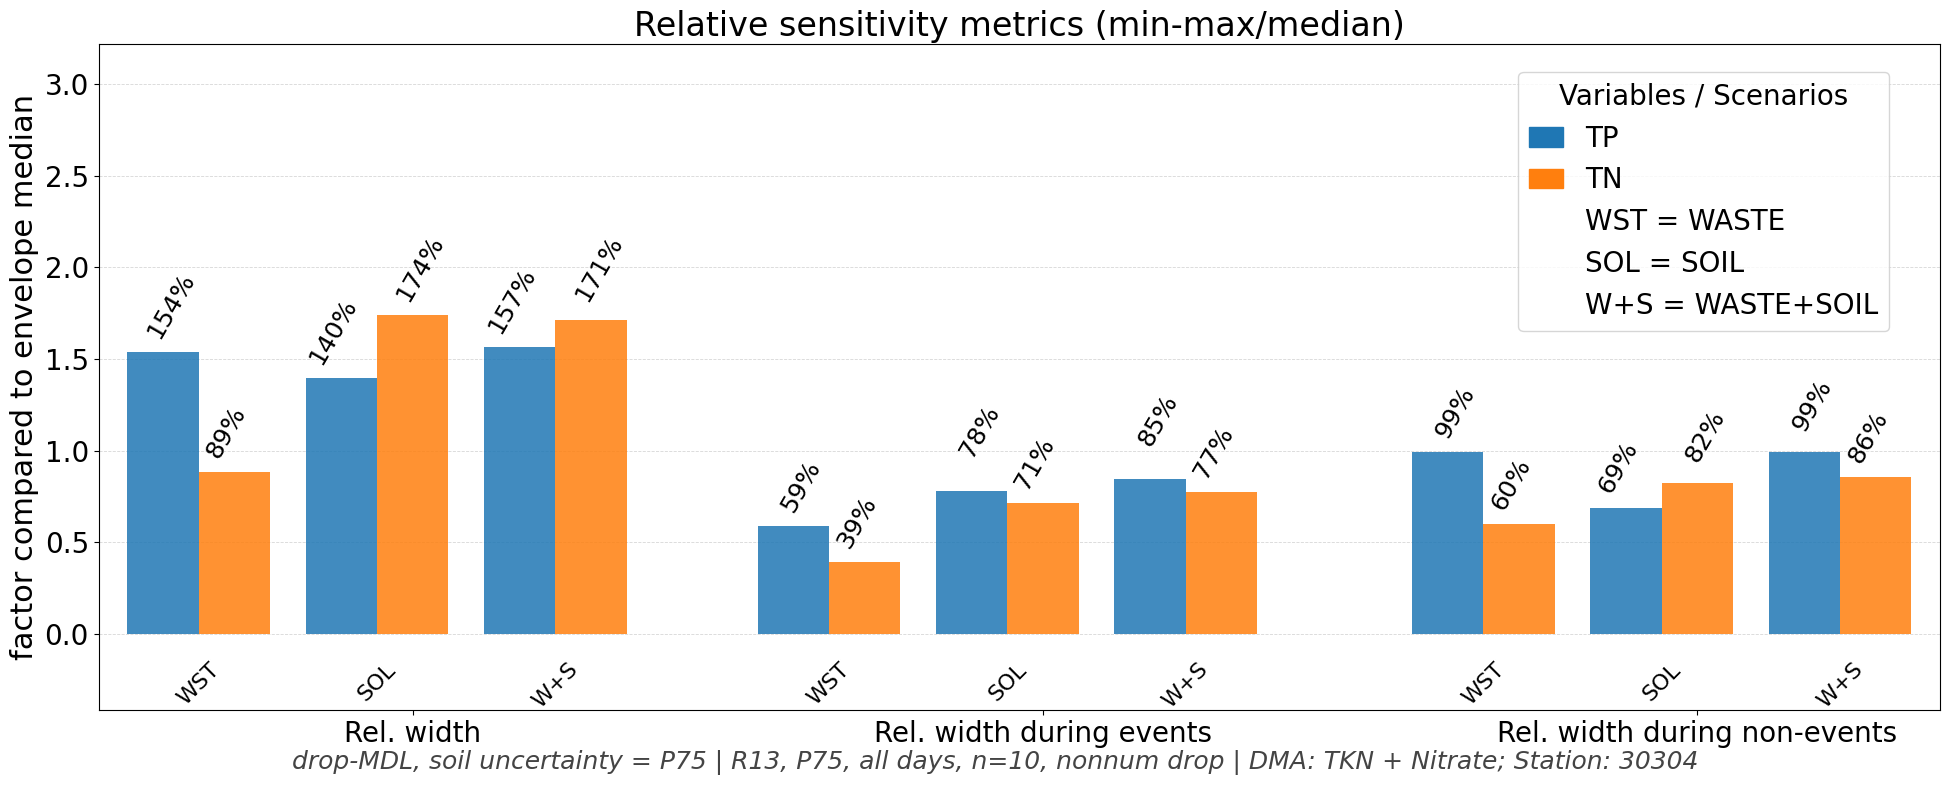

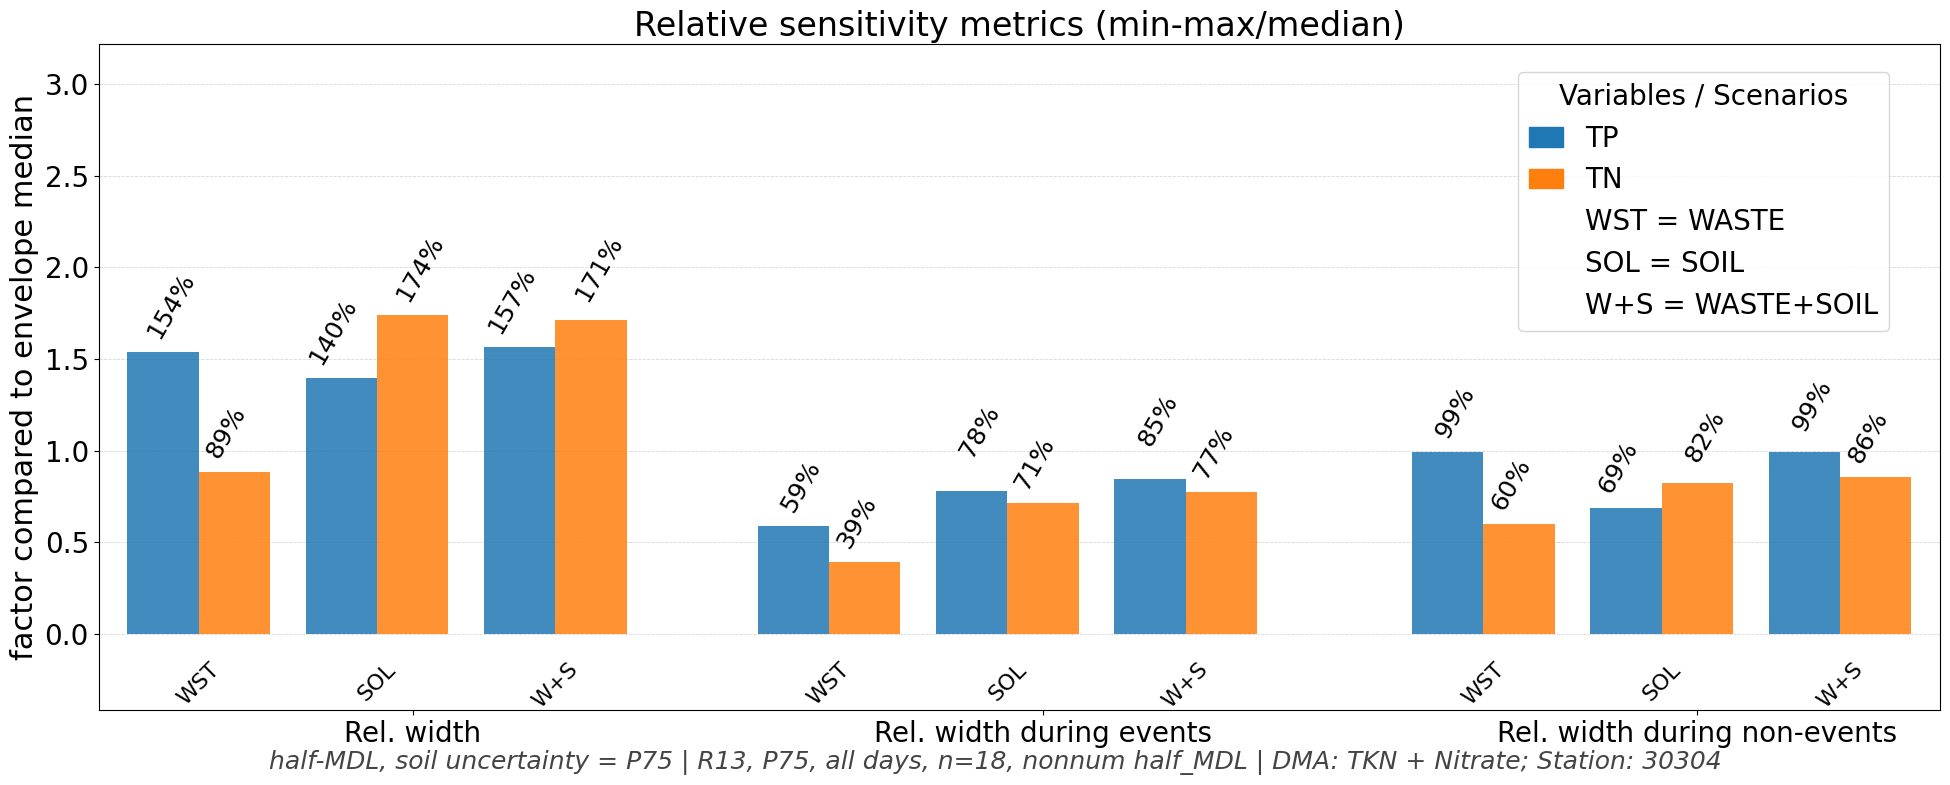

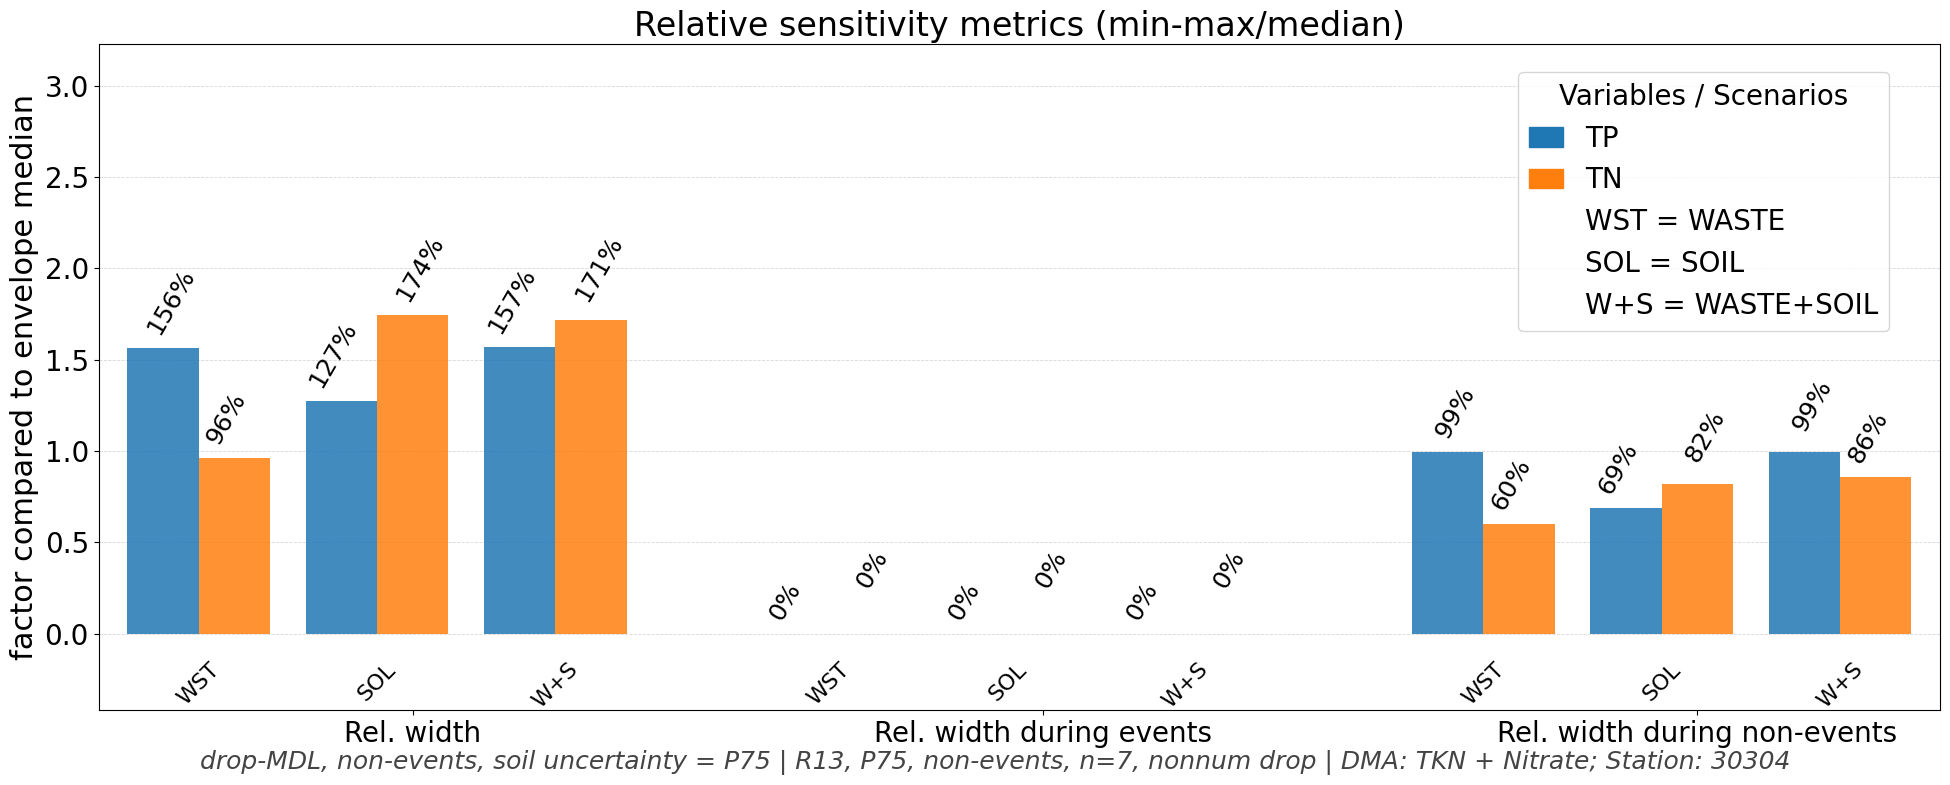

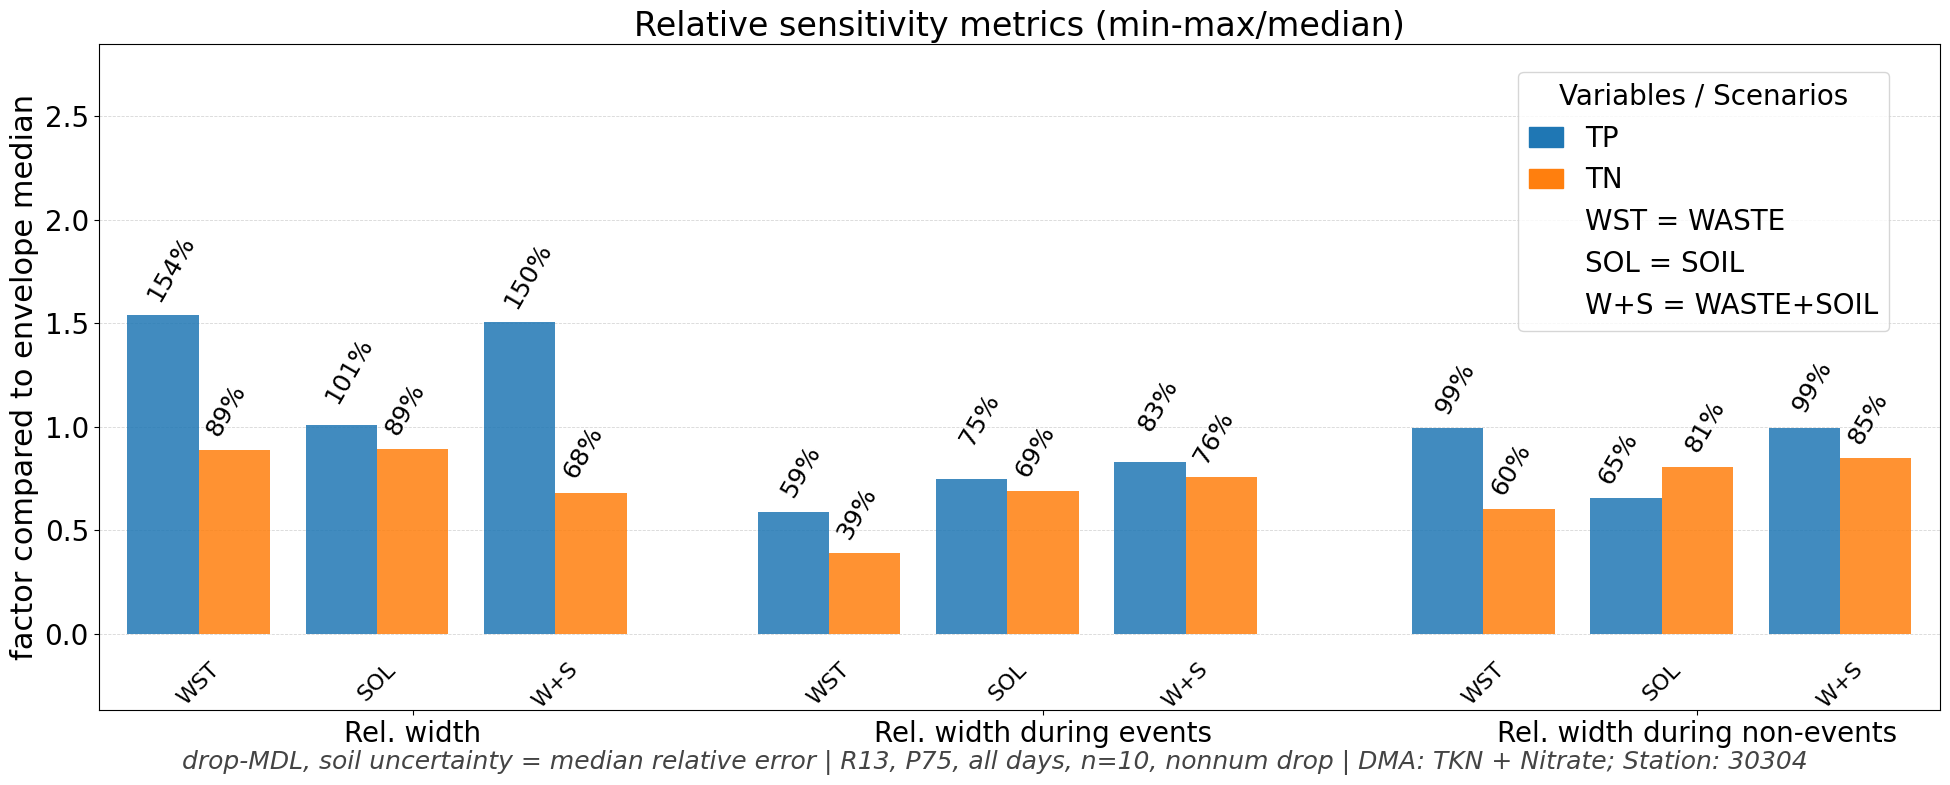

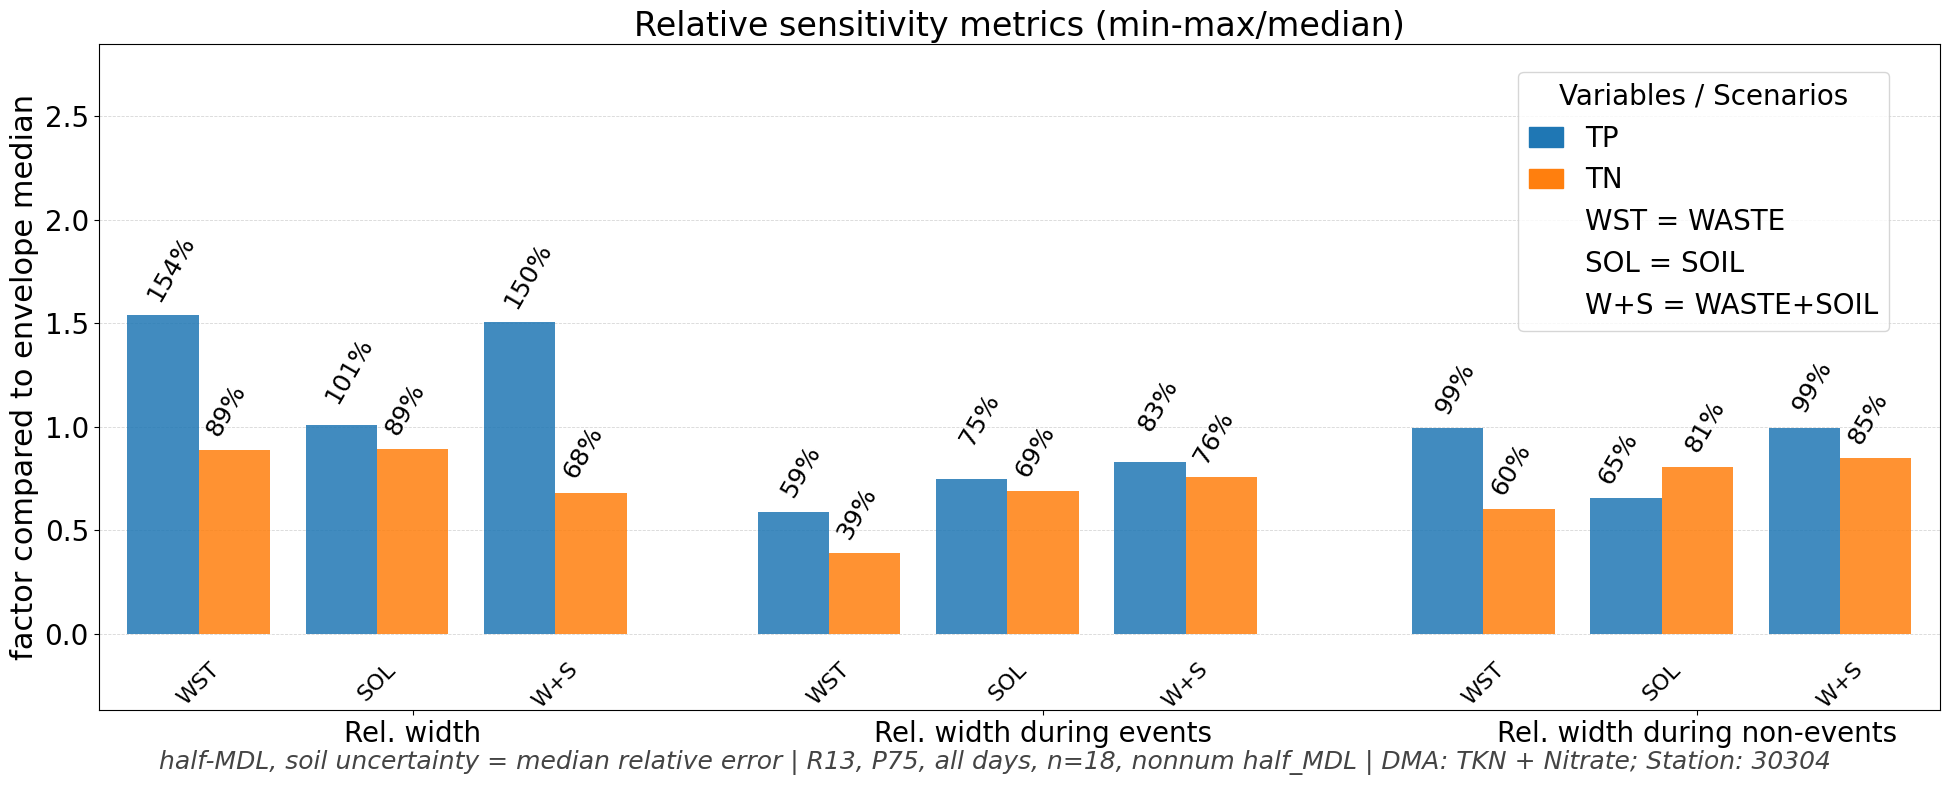

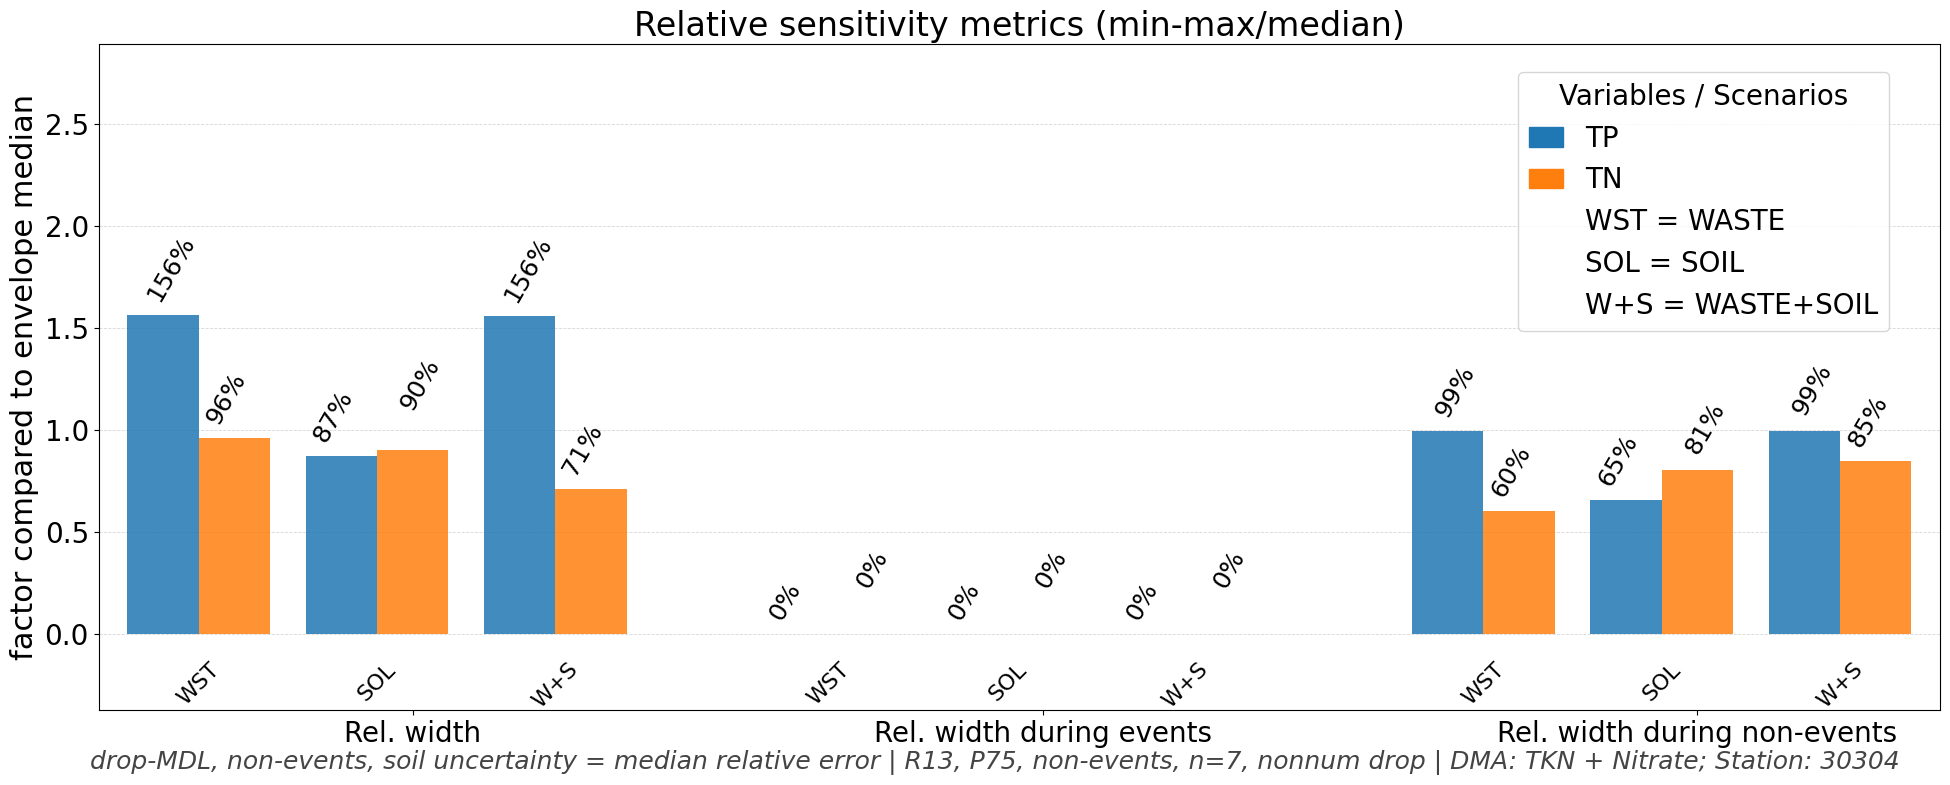

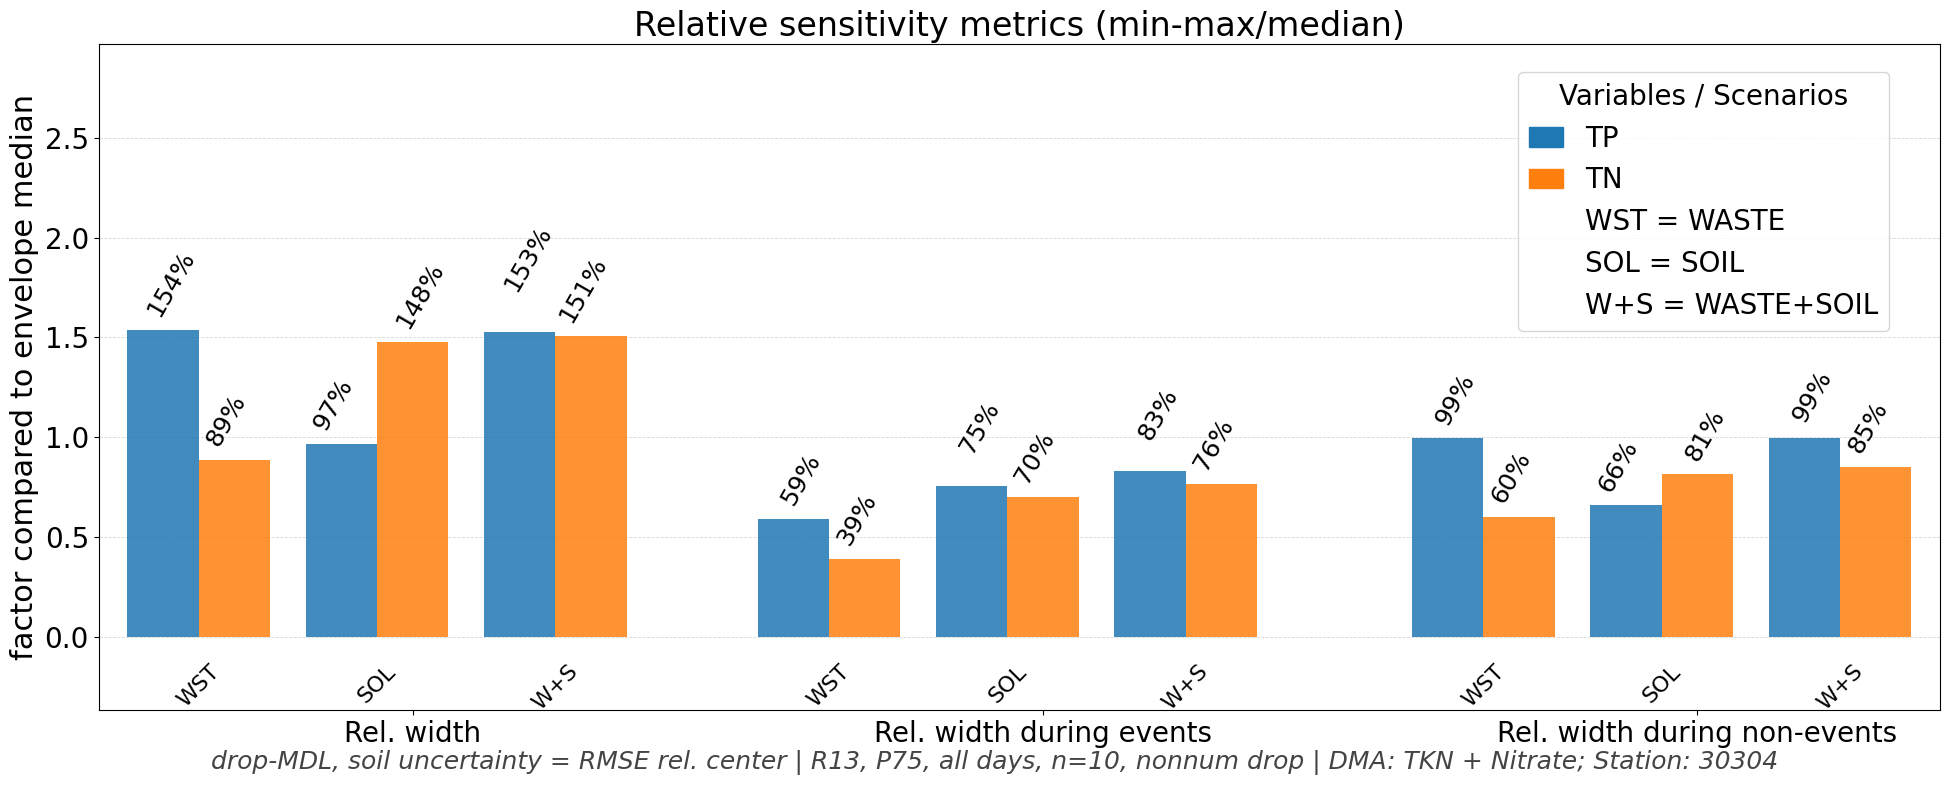

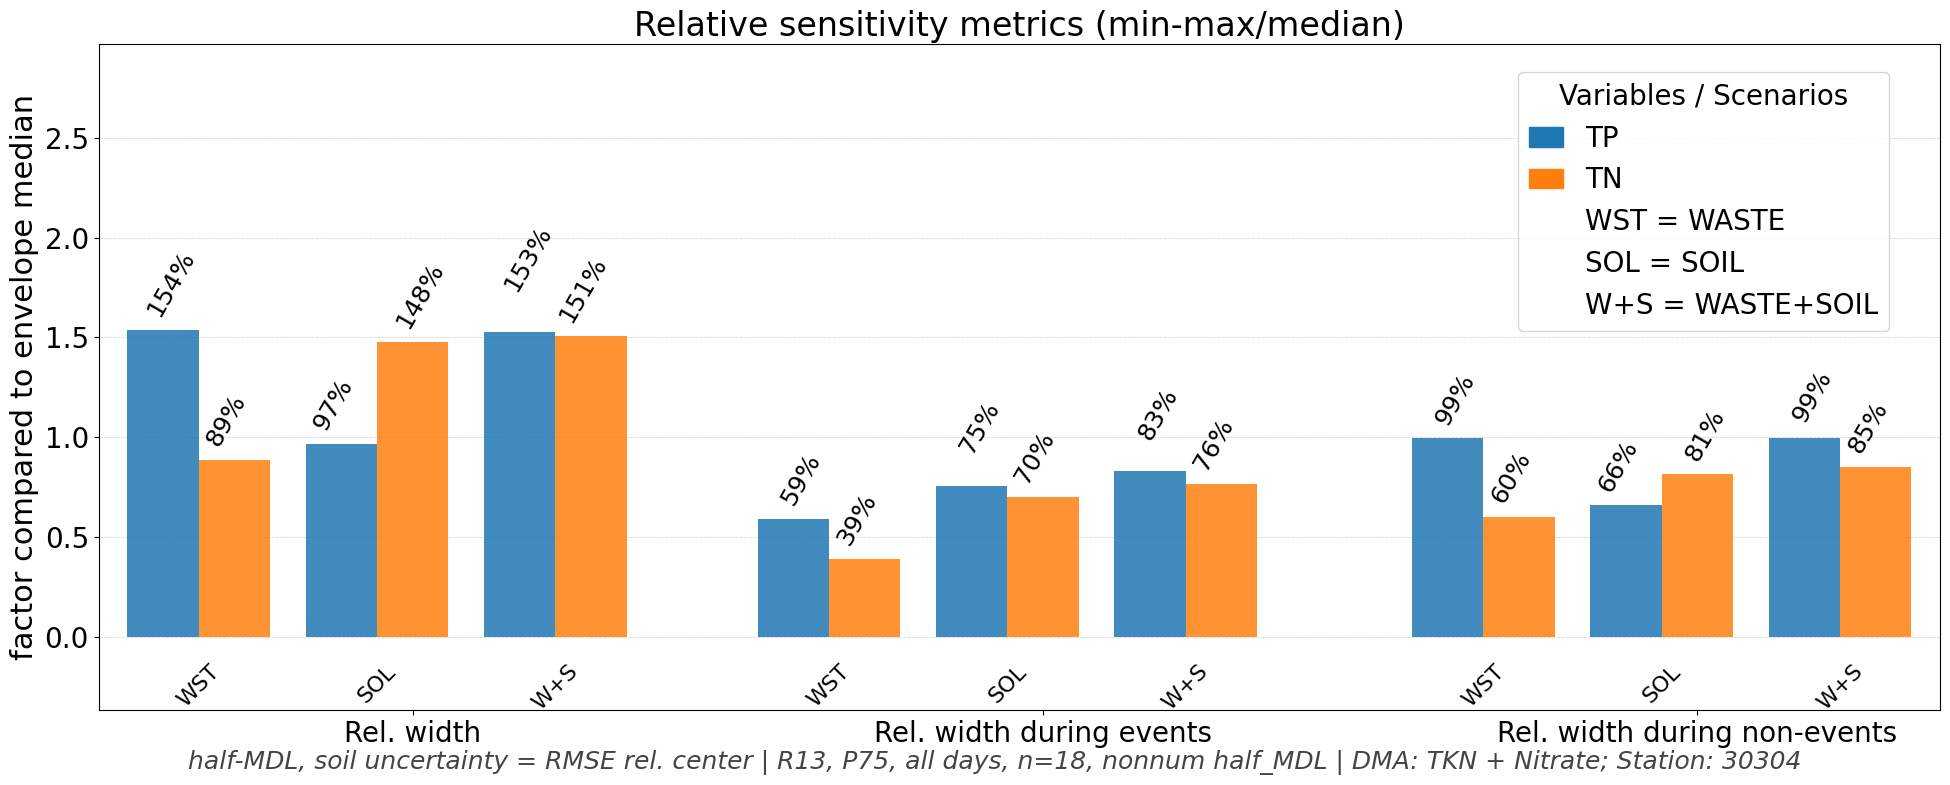

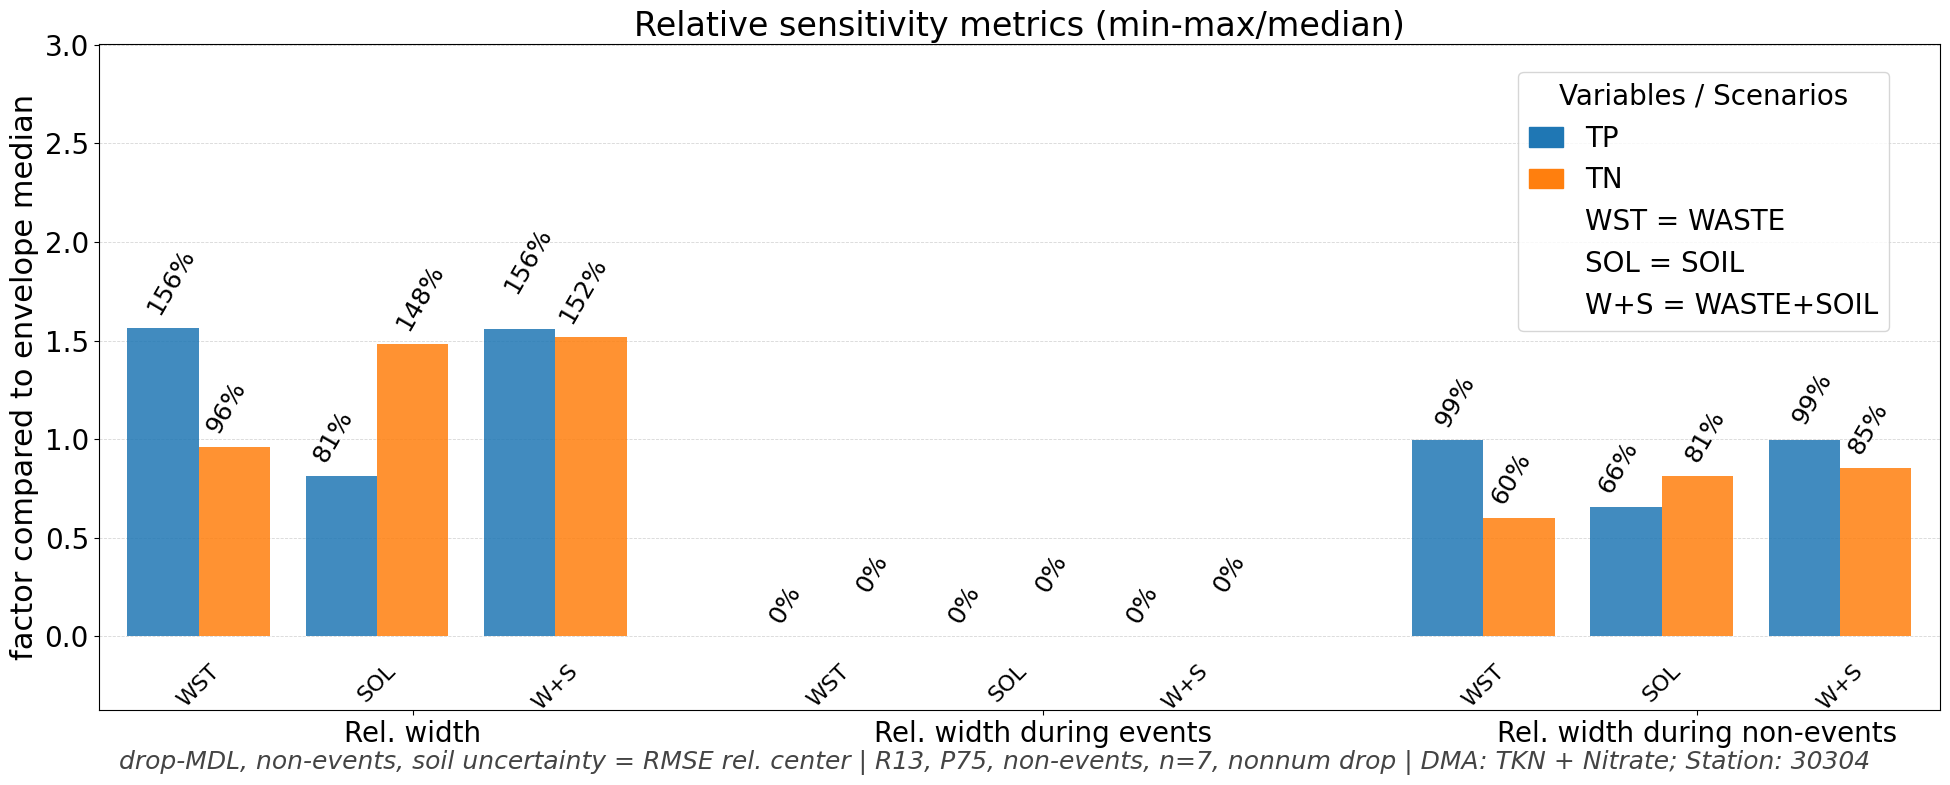

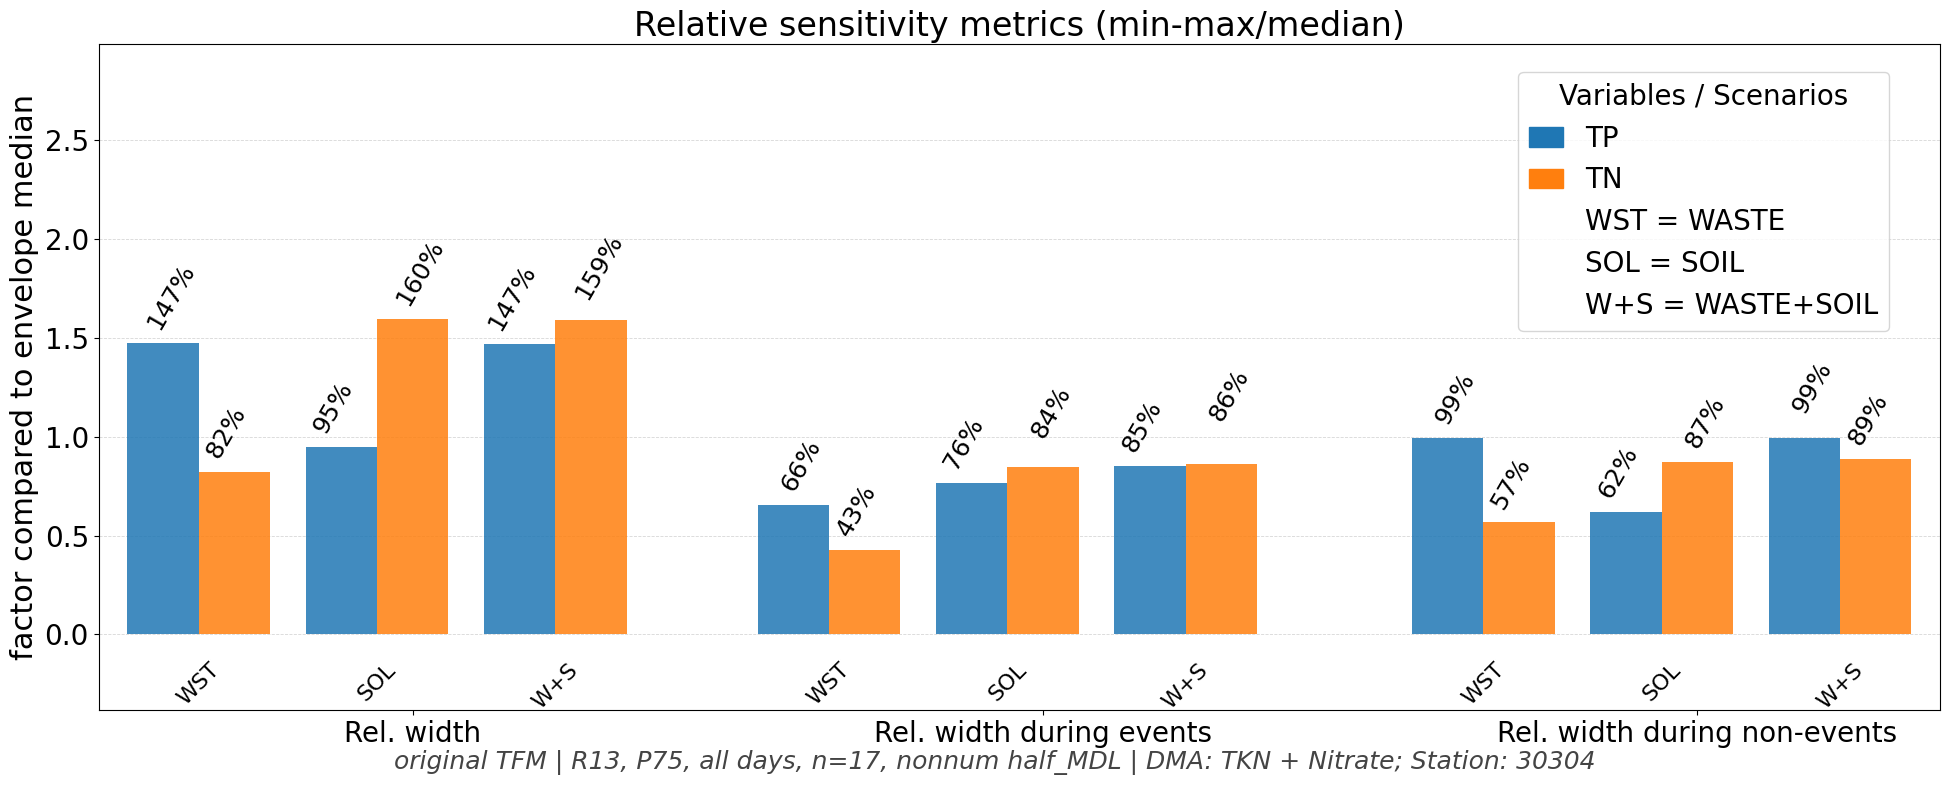


Finished chart 1 for all configured folders.
Chart 1 folder: runs_188_200_201__vars_tot_nkg_tot_pkg
  scenarios: ['WASTE', 'SOIL', 'WASTE+SOIL']
  variables: ['TP', 'TN']
Found 6 JSON files in C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\config\outputs\dashboard_stats\drop_mdl\runs_188_200_201__vars_tot_nkg_tot_pkg
  ✓ run-188: export_variable=tot-nkg, scenario=SOIL, variable=TN
  ✓ run-188: export_variable=tot-pkg, scenario=SOIL, variable=TP
  ✓ run-200: export_variable=tot-nkg, scenario=WASTE, variable=TN
  ✓ run-200: export_variable=tot-pkg, scenario=WASTE, variable=TP
  ✓ run-201: export_variable=tot-nkg, scenario=WASTE+SOIL, variable=TN
  ✓ run-201: export_variable=tot-pkg, scenario=WASTE+SOIL, variable=TP
  Note: no matched files were exported for runs: [153, 155, 157, 187, 189, 202, 203]

Built 6 export specs

Chart 1 folder: runs_188_200_201__vars_tot_nkg_tot_pkg
  scenarios: ['WASTE', 'SOIL', '

In [22]:
chart_1_metrics_by_folder = {}
chart_1_logs = []

for batch_folder in batch_folders:
    generated_specs, build_log = _capture_stdout(
        build_export_specs_from_folder,
        batch_folder,
        run_to_scenario,
        variable_map,
        verbose=True,
    )

    _ch1_actual_scenarios = list(dict.fromkeys(spec["scenario"] for spec in generated_specs))
    _ch1_actual_variables = list(dict.fromkeys(spec["variable"] for spec in generated_specs))
    _ch1_selected_scenarios = _ordered_present_values(_ch1_actual_scenarios, chart_scenario_order)
    _ch1_selected_variables = _ordered_present_values(_ch1_actual_variables, chart_variable_order)

    ch_1_auto_metrics = build_metrics_dict_from_stat_exports(
        generated_specs,
        ch1_semantic_labels,
        semantic_label_map=example_semantic_label_map,
        scenario_order=_ch1_selected_scenarios,
        variable_order=_ch1_selected_variables,
        format_mode="metadata",
        verbose=False,
    )

    chart_title, chart_subtitle = build_semantic_chart_title(
        batch_folder, generated_specs,
        "Relative sensitivity metrics (min-max/median)",
        title_metadata_parts=title_metadata_parts,
        title_folder_label_map=title_folder_label_map,
    )

    fig, ax = plot_nested_sensitivity_bars(
        ch_1_auto_metrics,
        variables_order=_ch1_selected_variables,
        title=chart_title,
        subtitle=chart_subtitle,
        y_label="factor compared to envelope median",
        figsize=(20, 8),
        scenarios_order=_ch1_selected_scenarios,
        stats_order=ch1_semantic_labels,
        stat_label_map={
            "Model relative width (min-max / median)": "Rel. width",
            "Relative width (event days)": "Rel. width during events",
            "Relative width (non-event days)": "Rel. width during non-events",
        },
        abbreviations=chart_abbreviations,
        annotate_rotation=60,
        annot_fs=18,
        scenario_fs=16,
        tick_fs=20,
        label_fs=22,
        title_fs=24,
        legend_fs=20,
        legend_outside=False,
        legend_loc="upper right",
        legend_bbox=(0.98, 0.98),
        tight_layout_rect=(0.0, 0.02, 0.98, 0.98),
        inside_legend_top_margin_scale=0.82,
        edge_bar_padding=0.90,
        label_separation_scale=0.10,
    )
    plt.show()

    saved_path, save_log = _capture_stdout(
        _save_chart_figure,
        fig,
        batch_folder.name,
        "chart_1_relative_width",
        save_enabled=save_individual_chart_images,
        output_root=saved_chart_root,
        dpi=saved_chart_dpi,
    )
    plt.close(fig)

    chart_1_metrics_by_folder[batch_folder.name] = ch_1_auto_metrics
    chart_results_by_folder.setdefault(batch_folder.name, {})["chart_1_metrics"] = ch_1_auto_metrics
    chart_results_by_folder[batch_folder.name]["chart_1_saved_path"] = saved_path

    chart_1_logs.append(f"Chart 1 folder: {batch_folder.name}")
    chart_1_logs.append(f"  scenarios: {_ch1_selected_scenarios}")
    chart_1_logs.append(f"  variables: {_ch1_selected_variables}")
    if build_log.strip():
        chart_1_logs.append(build_log.rstrip())
    if save_log.strip():
        chart_1_logs.append(save_log.rstrip())
    chart_1_logs.append("")

print("\nFinished chart 1 for all configured folders.")
print("\n".join(line for line in chart_1_logs if line is not None))


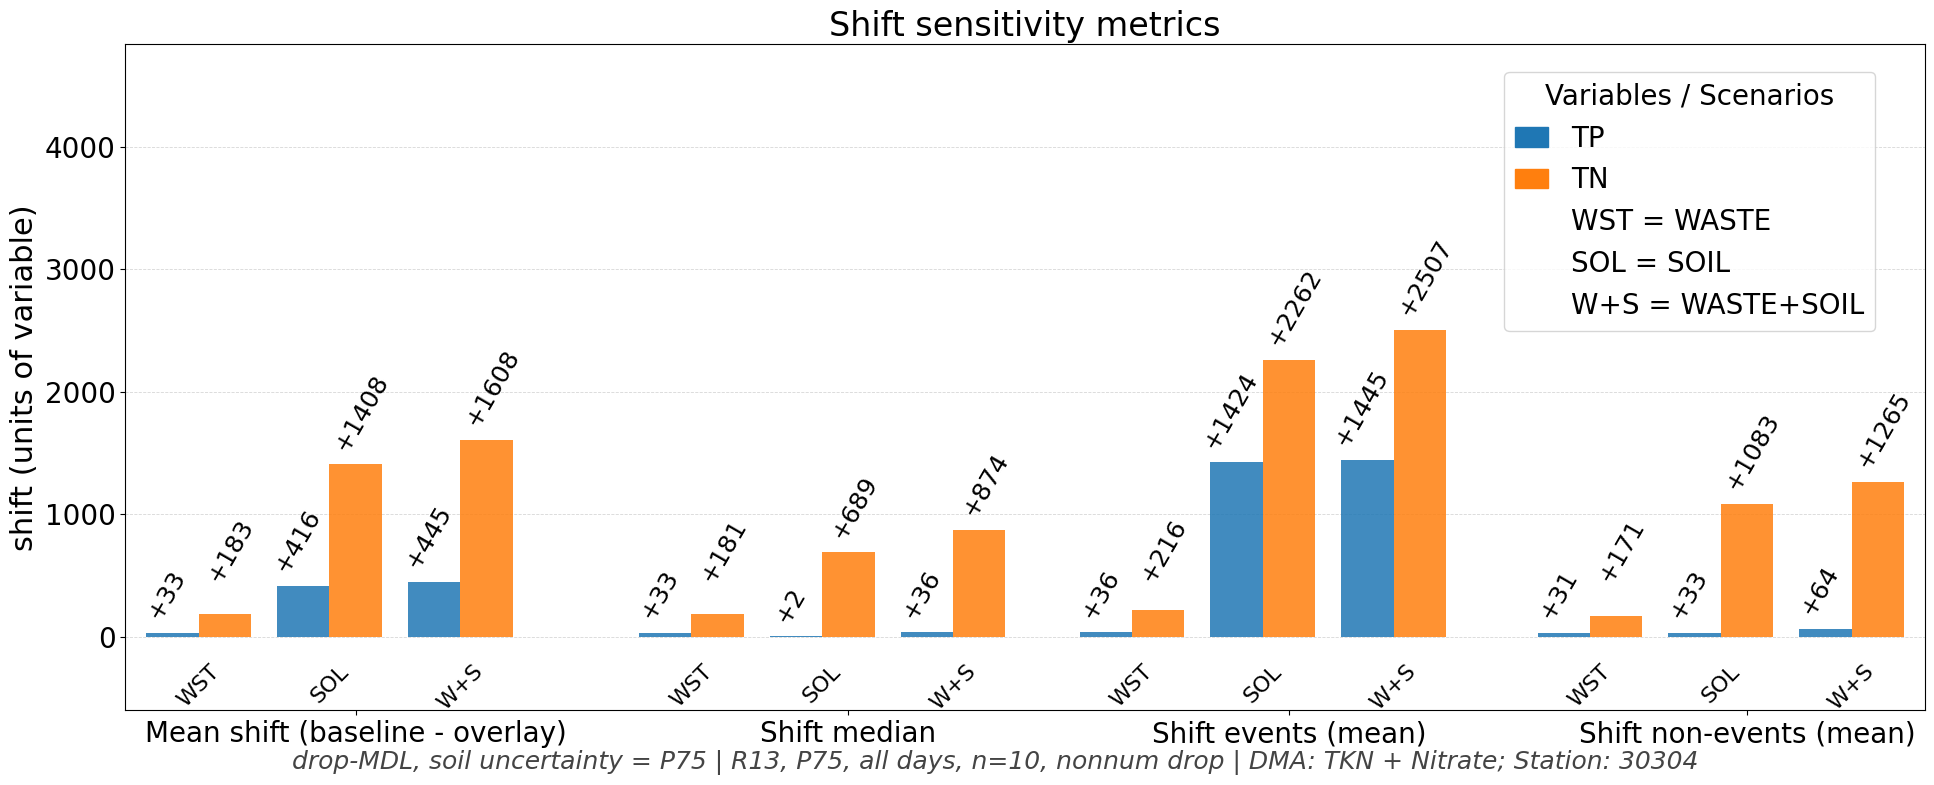

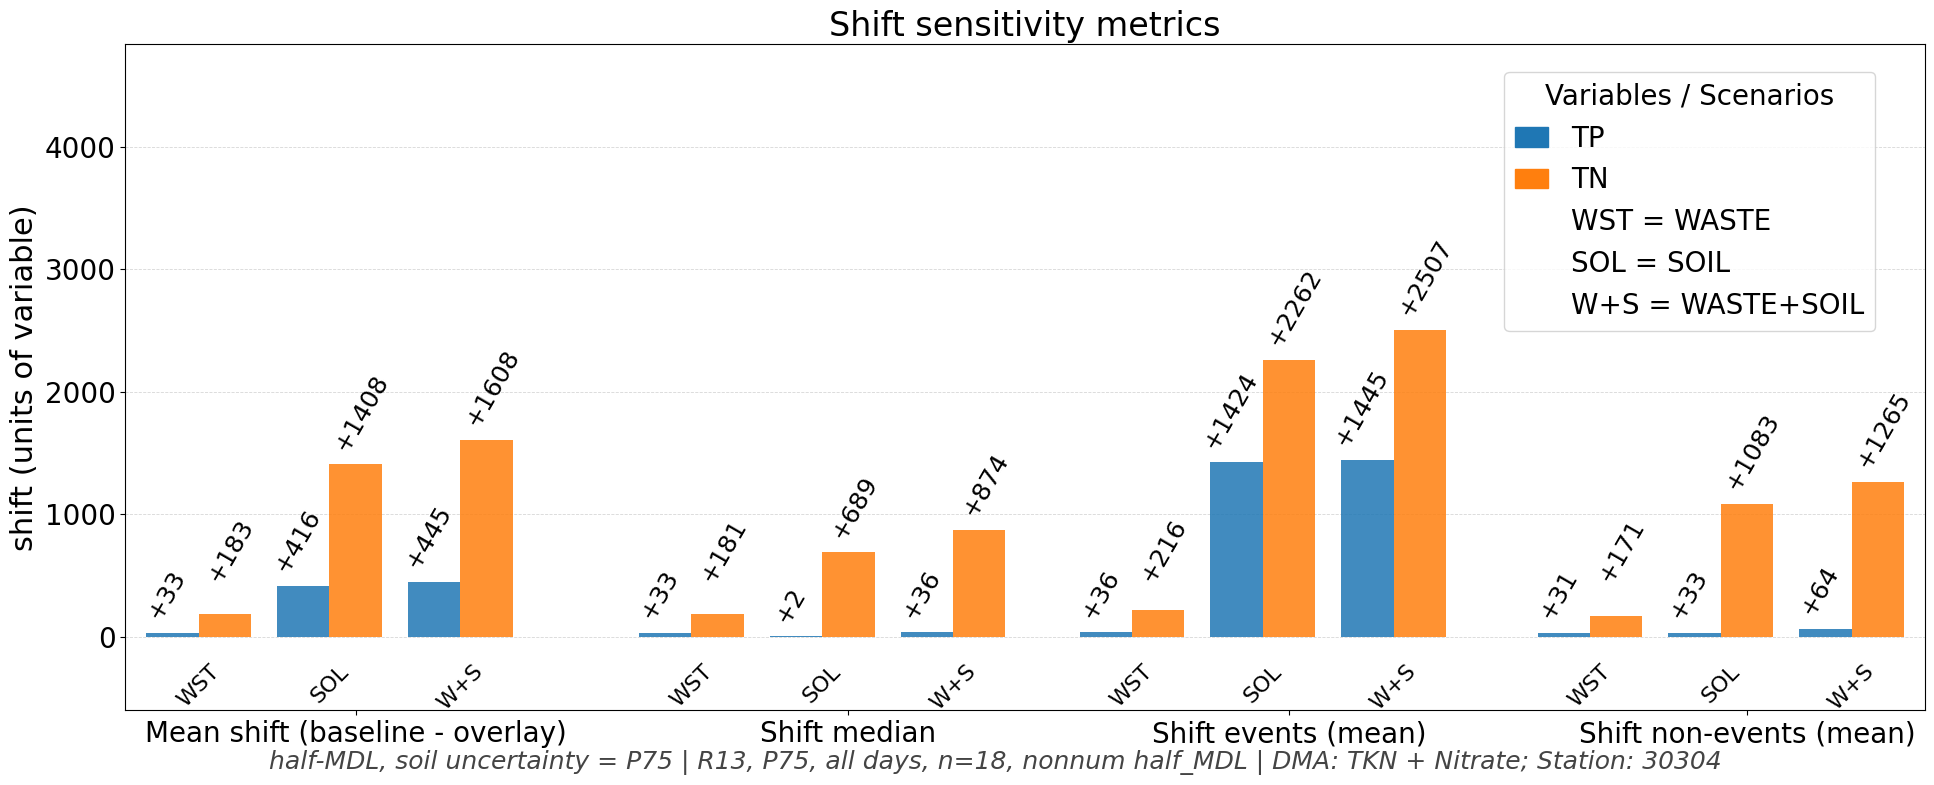

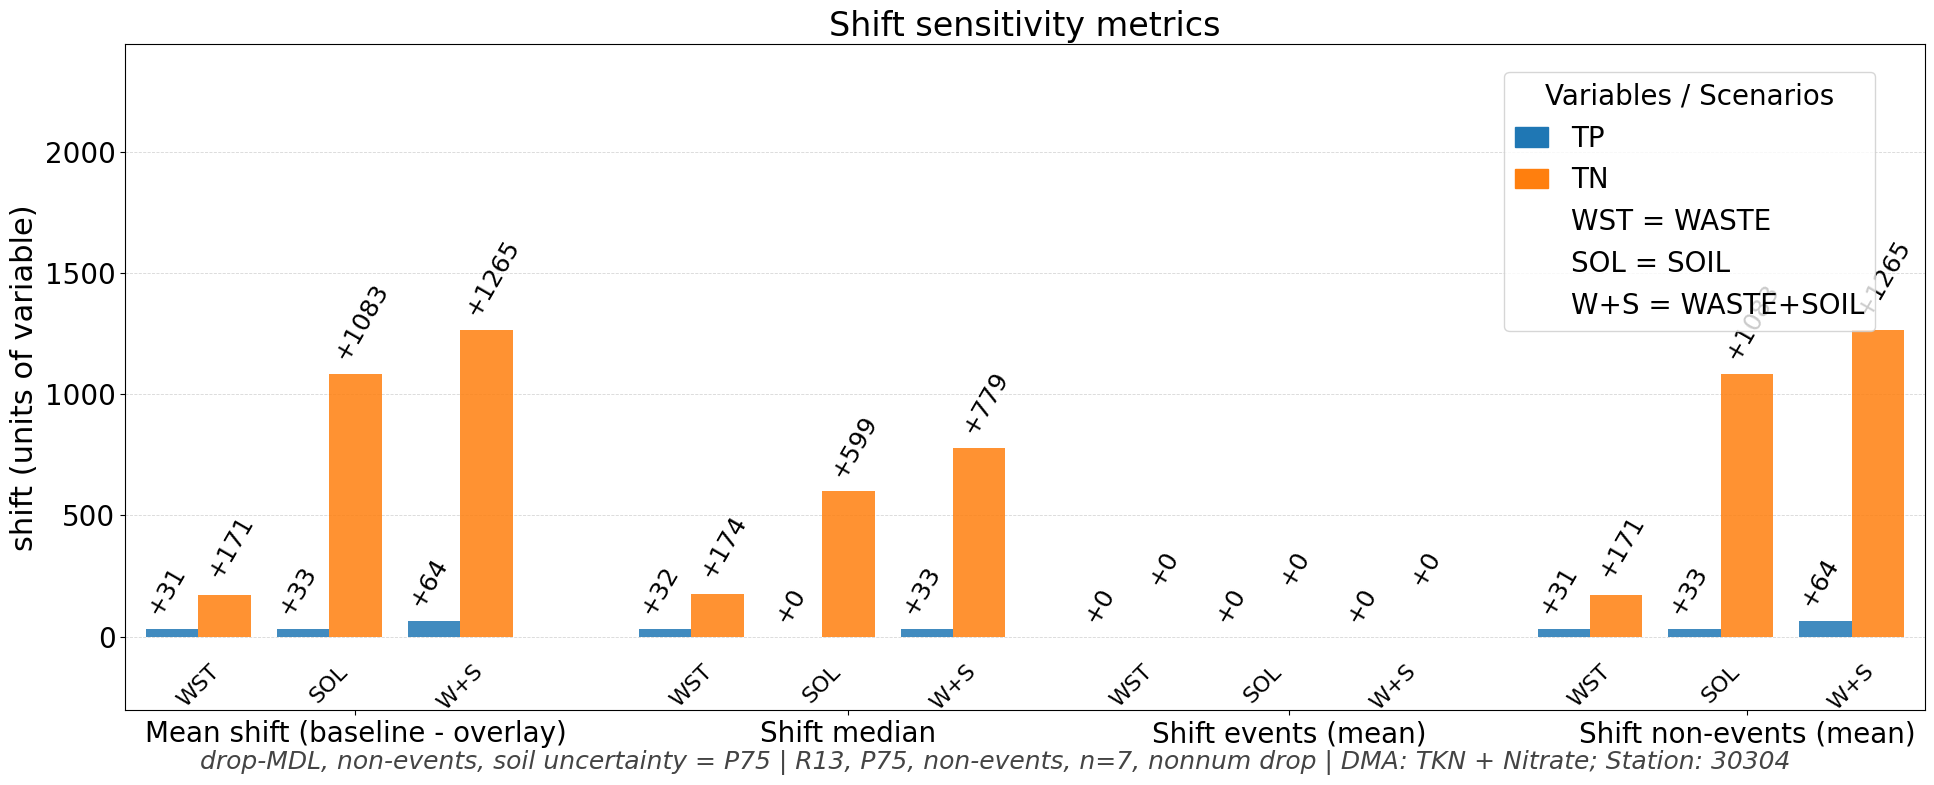

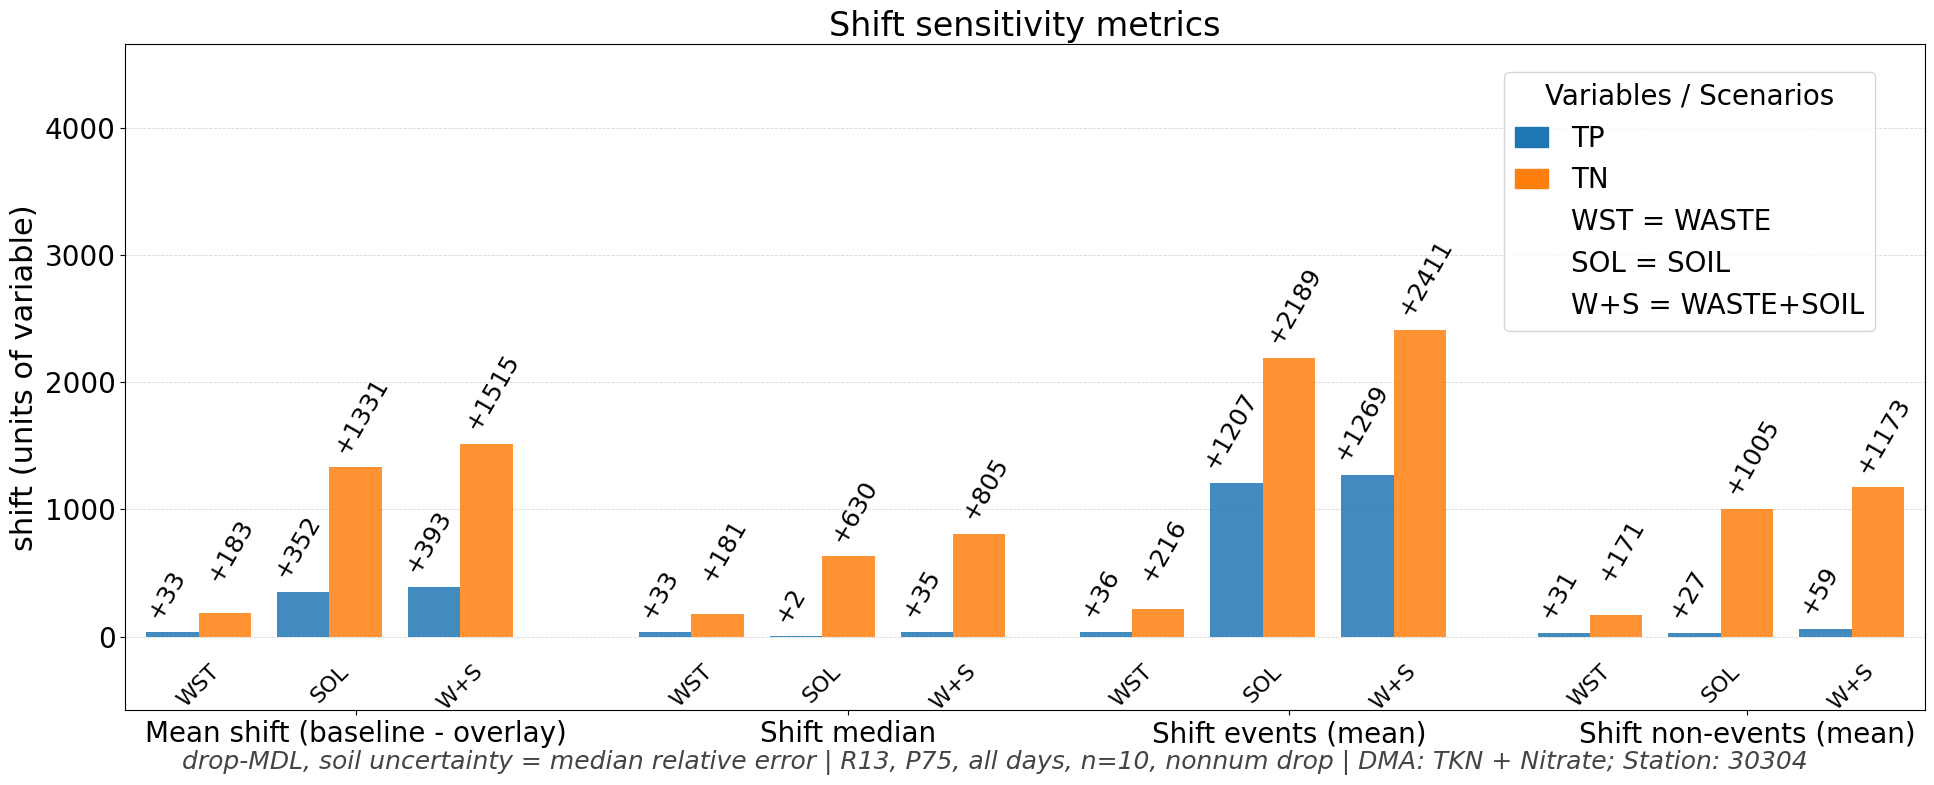

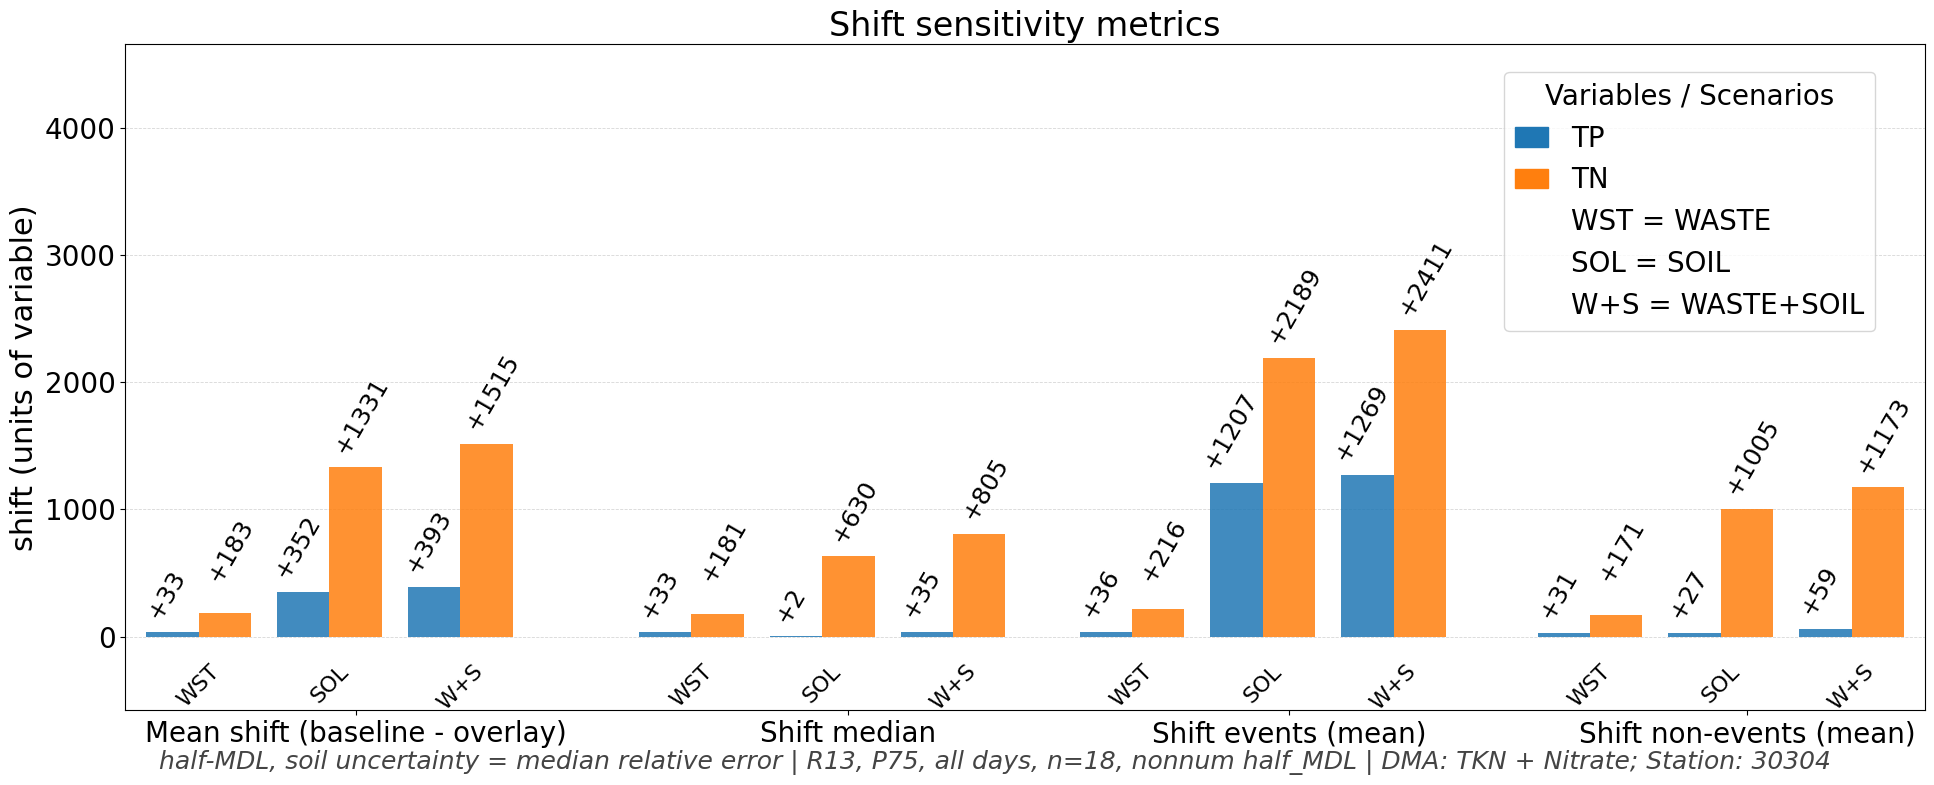

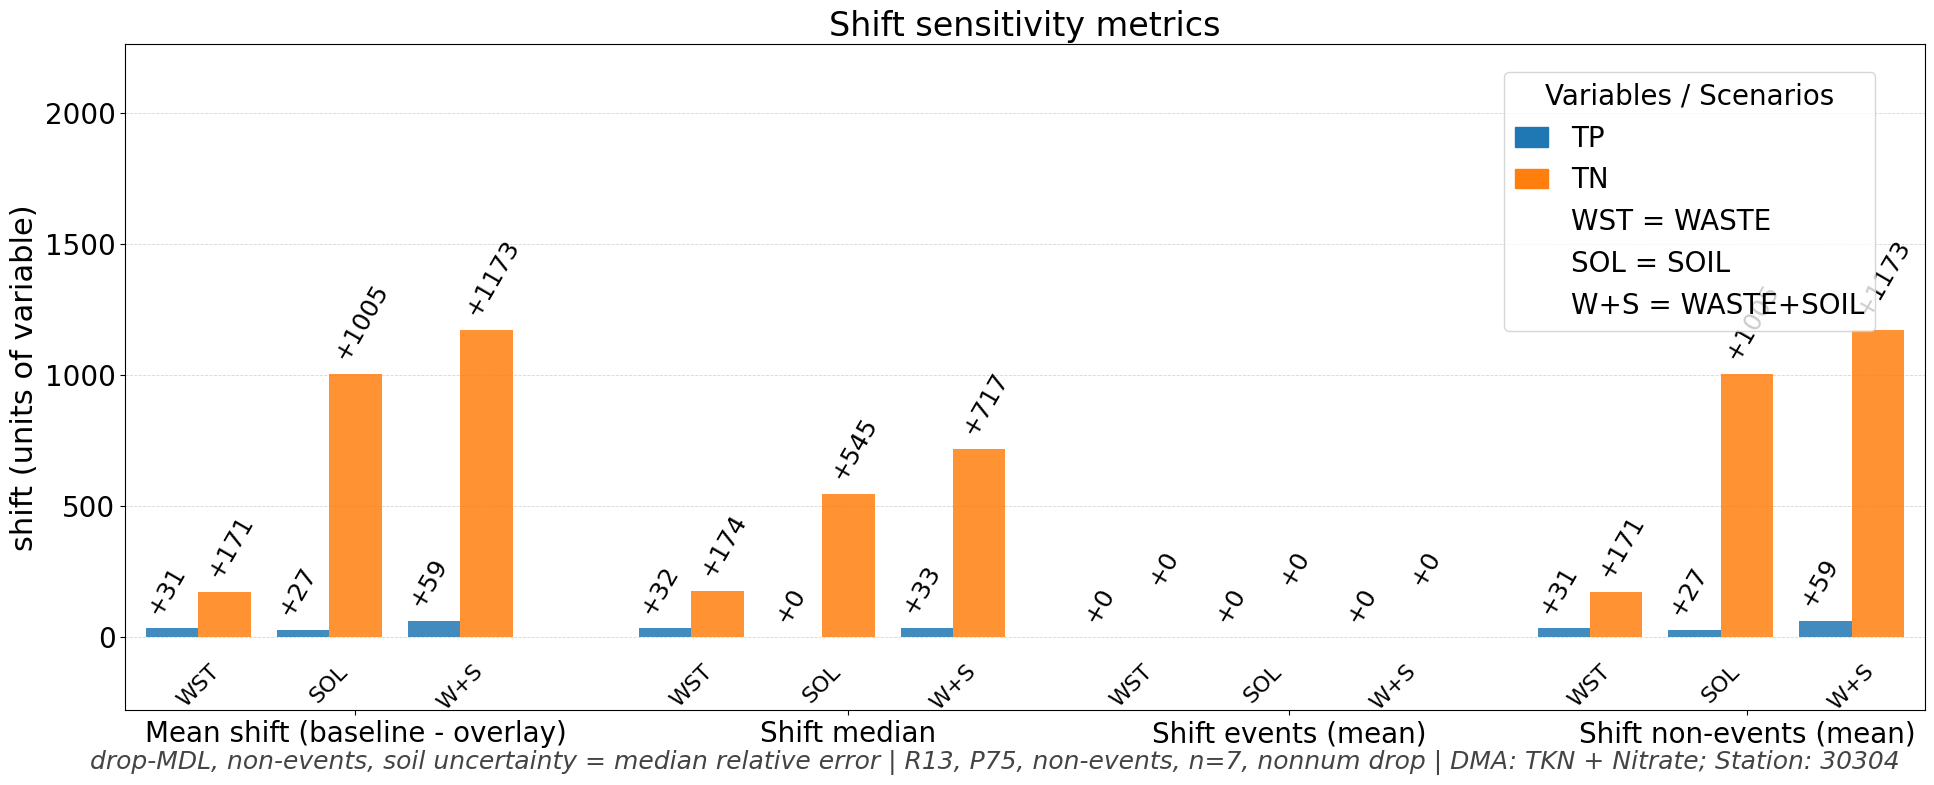

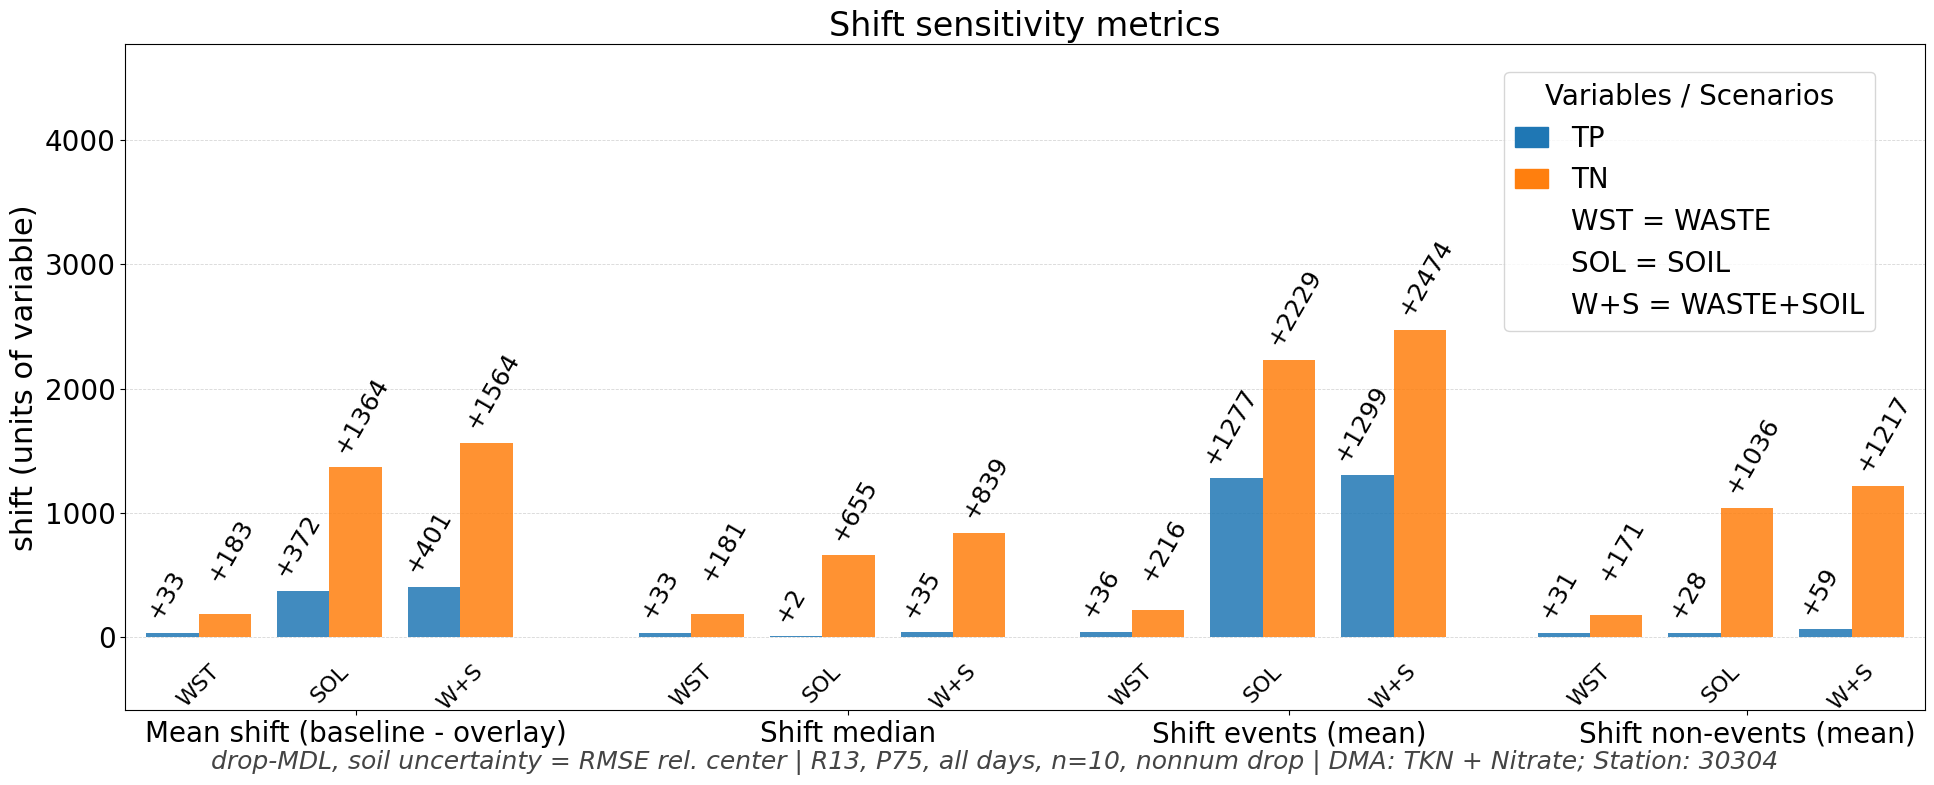

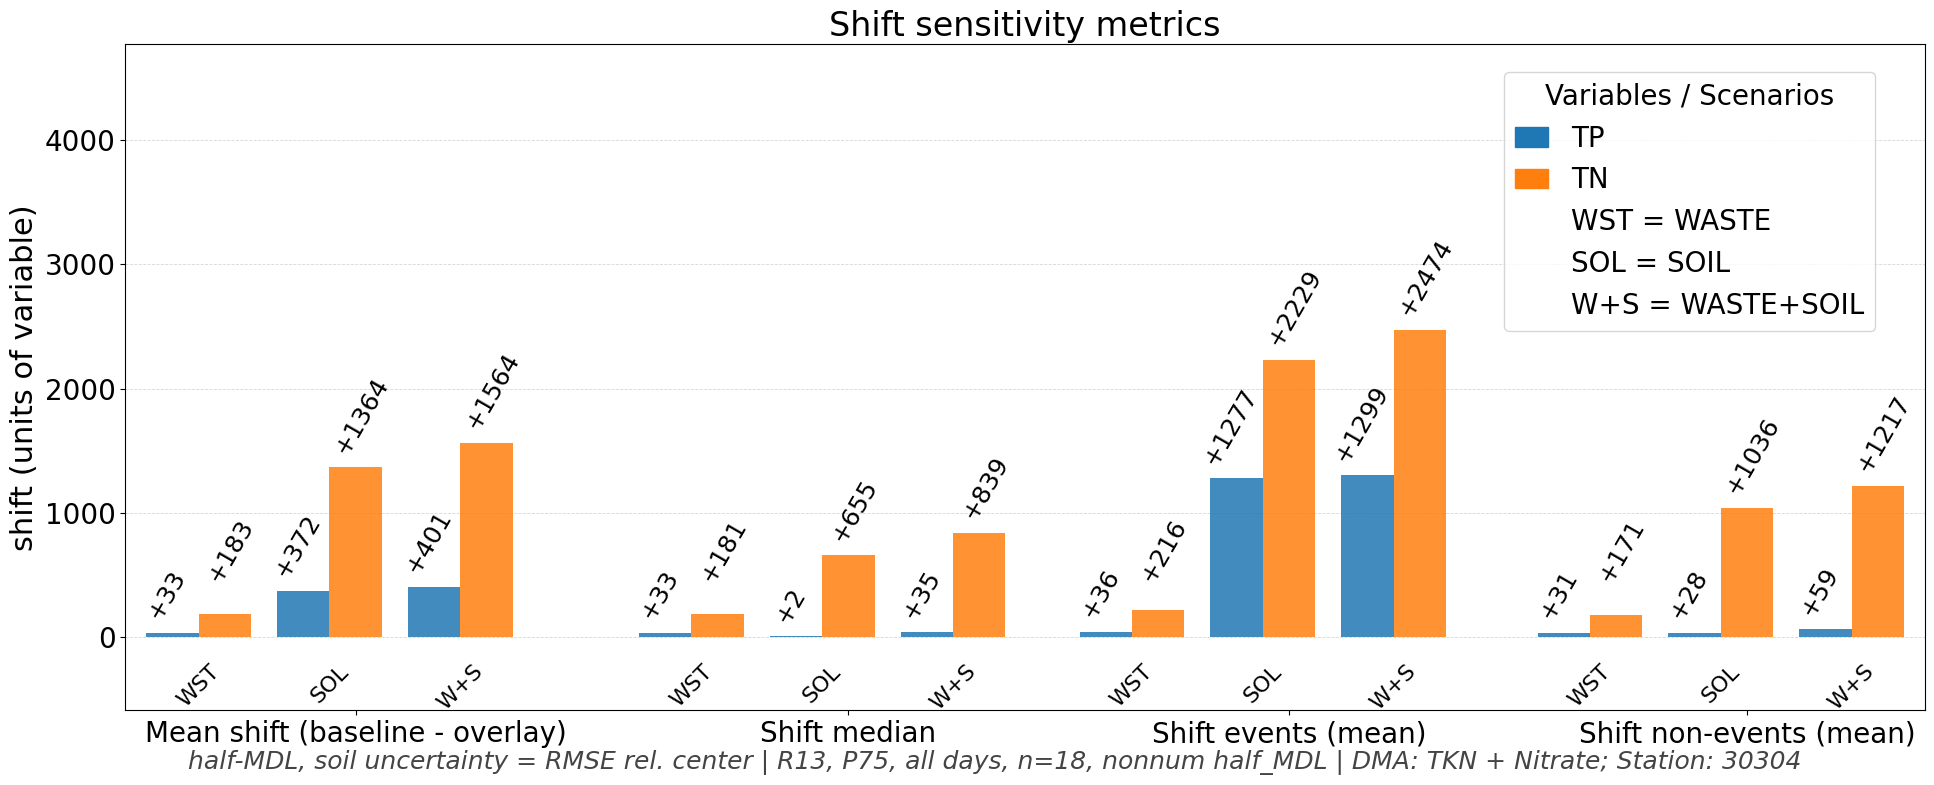

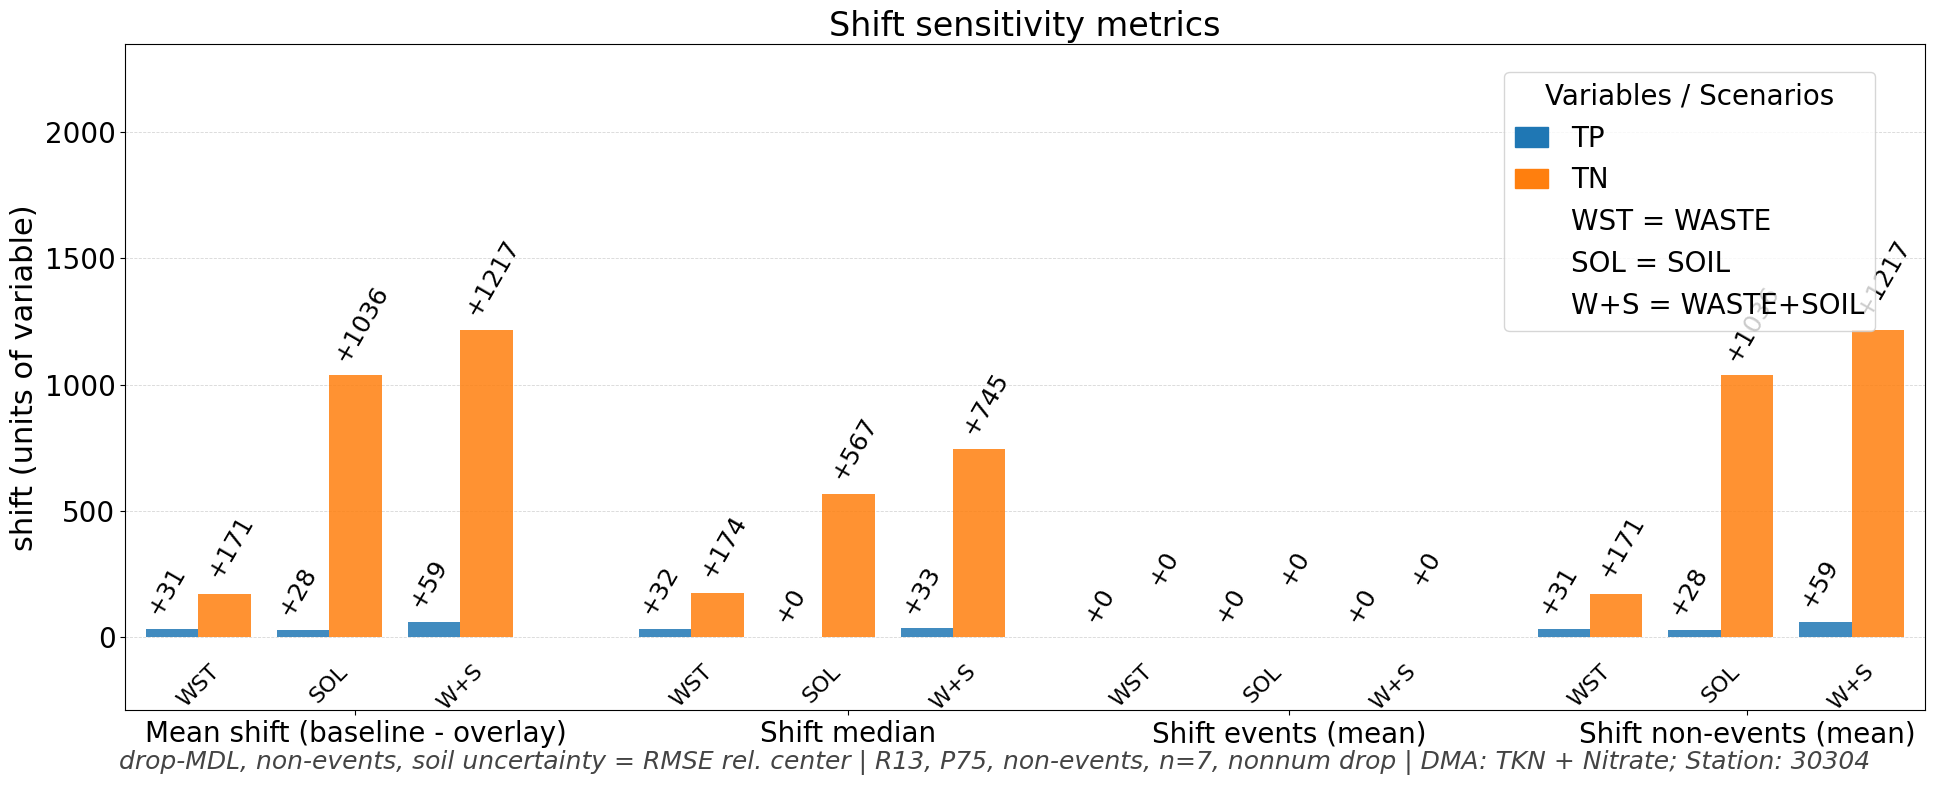

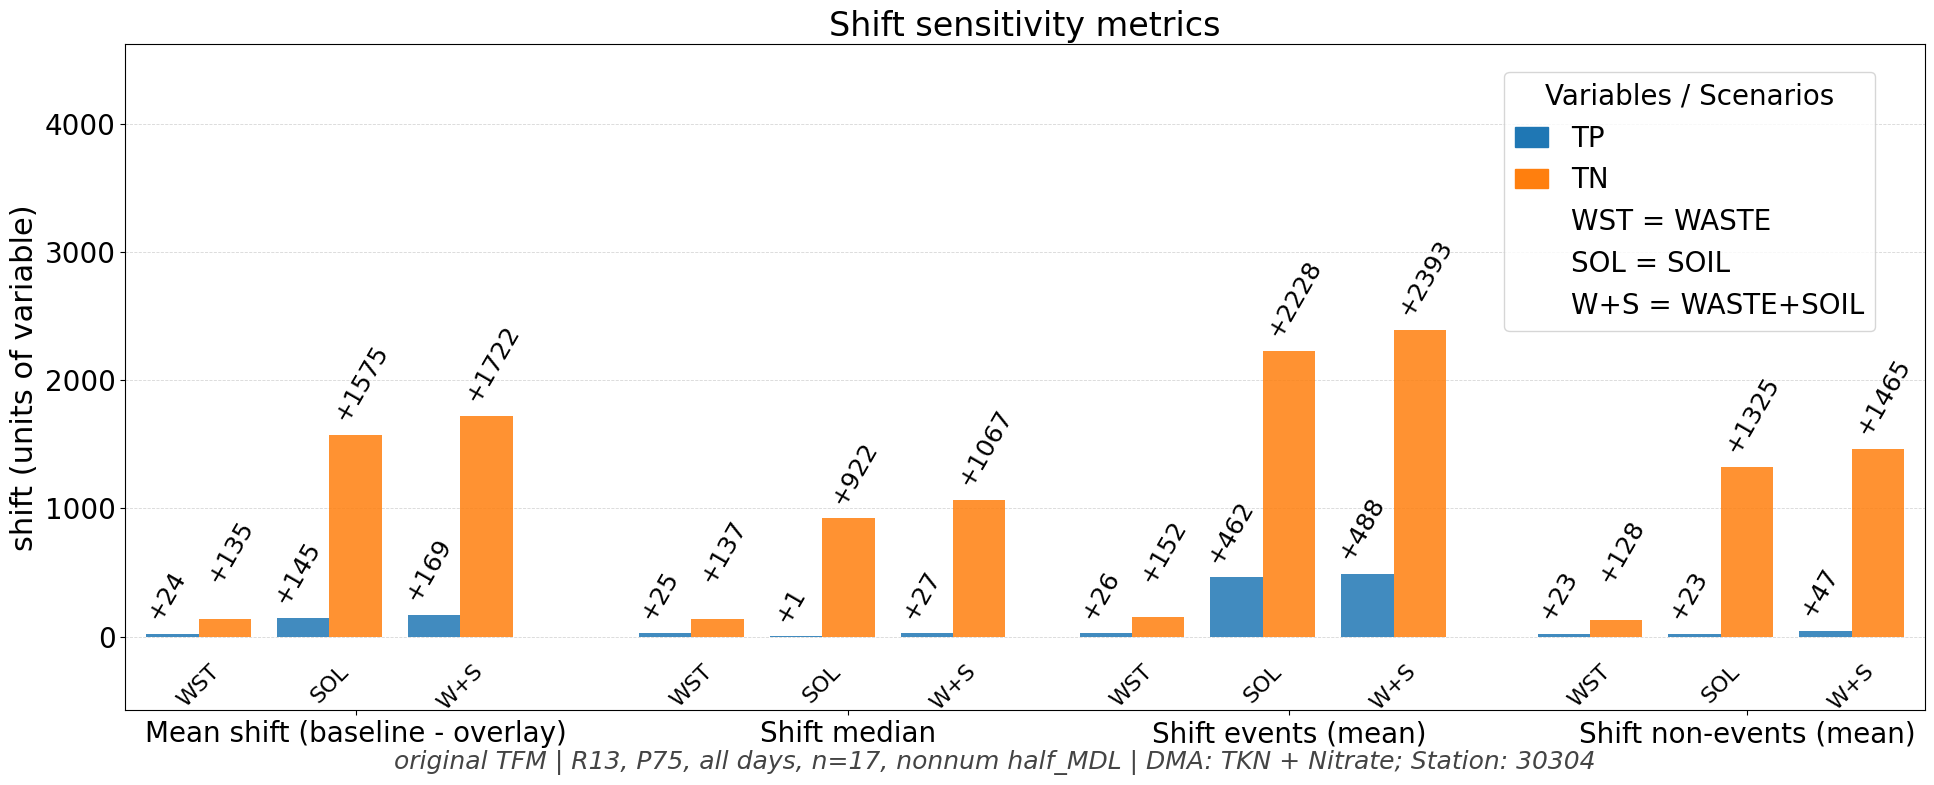


Finished chart 2 for all configured folders.
Chart 2 folder: runs_188_200_201__vars_tot_nkg_tot_pkg
  scenarios: ['WASTE', 'SOIL', 'WASTE+SOIL']
  variables: ['TP', 'TN']
Found 6 JSON files in C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\config\outputs\dashboard_stats\drop_mdl\runs_188_200_201__vars_tot_nkg_tot_pkg
  ✓ run-188: export_variable=tot-nkg, scenario=SOIL, variable=TN
  ✓ run-188: export_variable=tot-pkg, scenario=SOIL, variable=TP
  ✓ run-200: export_variable=tot-nkg, scenario=WASTE, variable=TN
  ✓ run-200: export_variable=tot-pkg, scenario=WASTE, variable=TP
  ✓ run-201: export_variable=tot-nkg, scenario=WASTE+SOIL, variable=TN
  ✓ run-201: export_variable=tot-pkg, scenario=WASTE+SOIL, variable=TP
  Note: no matched files were exported for runs: [153, 155, 157, 187, 189, 202, 203]

Built 6 export specs

Chart 2 folder: runs_188_200_201__vars_tot_nkg_tot_pkg
  scenarios: ['WASTE', 'SOIL', '

In [23]:
chart_2_metrics_by_folder = {}
chart_2_logs = []

for batch_folder in batch_folders:
    generated_specs, build_log = _capture_stdout(
        build_export_specs_from_folder,
        batch_folder,
        run_to_scenario,
        variable_map,
        verbose=True,
    )

    _ch2_actual_scenarios = list(dict.fromkeys(spec["scenario"] for spec in generated_specs))
    _ch2_actual_variables = list(dict.fromkeys(spec["variable"] for spec in generated_specs))
    _ch2_selected_scenarios = _ordered_present_values(_ch2_actual_scenarios, chart_scenario_order)
    _ch2_selected_variables = _ordered_present_values(_ch2_actual_variables, chart_variable_order)

    ch_2_auto_metrics = build_metrics_dict_from_stat_exports(
        generated_specs,
        ch2_semantic_labels,
        semantic_label_map=example_semantic_label_map,
        scenario_order=_ch2_selected_scenarios,
        variable_order=_ch2_selected_variables,
        format_mode="metadata",
        verbose=False,
    )

    chart_title, chart_subtitle = build_semantic_chart_title(
        batch_folder, generated_specs,
        "Shift sensitivity metrics",
        title_metadata_parts=title_metadata_parts,
        title_folder_label_map=title_folder_label_map,
    )

    fig, ax = plot_nested_sensitivity_bars(
        ch_2_auto_metrics,
        title=chart_title,
        subtitle=chart_subtitle,
        variables_order=_ch2_selected_variables,
        scenarios_order=_ch2_selected_scenarios,
        abbreviations=chart_abbreviations,
        y_label="shift (units of variable)",
        figsize=(20, 8),
        annotate_rotation=60,
        annot_fs=18,
        scenario_fs=16,
        tick_fs=20,
        label_fs=22,
        title_fs=24,
        legend_fs=20,
        legend_outside=False,
        legend_loc="upper right",
        legend_bbox=(0.98, 0.98),
        tight_layout_rect=(0.0, 0.02, 0.98, 0.98),
        inside_legend_top_margin_scale=0.90,
        edge_bar_padding=0.90,
        label_separation_scale=0.12,
    )
    plt.show()

    saved_path, save_log = _capture_stdout(
        _save_chart_figure,
        fig,
        batch_folder.name,
        "chart_2_shift",
        save_enabled=save_individual_chart_images,
        output_root=saved_chart_root,
        dpi=saved_chart_dpi,
    )
    plt.close(fig)

    chart_2_metrics_by_folder[batch_folder.name] = ch_2_auto_metrics
    chart_results_by_folder.setdefault(batch_folder.name, {})["chart_2_metrics"] = ch_2_auto_metrics
    chart_results_by_folder[batch_folder.name]["chart_2_saved_path"] = saved_path

    chart_2_logs.append(f"Chart 2 folder: {batch_folder.name}")
    chart_2_logs.append(f"  scenarios: {_ch2_selected_scenarios}")
    chart_2_logs.append(f"  variables: {_ch2_selected_variables}")
    if build_log.strip():
        chart_2_logs.append(build_log.rstrip())
    if save_log.strip():
        chart_2_logs.append(save_log.rstrip())
    chart_2_logs.append("")

print("\nFinished chart 2 for all configured folders.")
print("\n".join(line for line in chart_2_logs if line is not None))


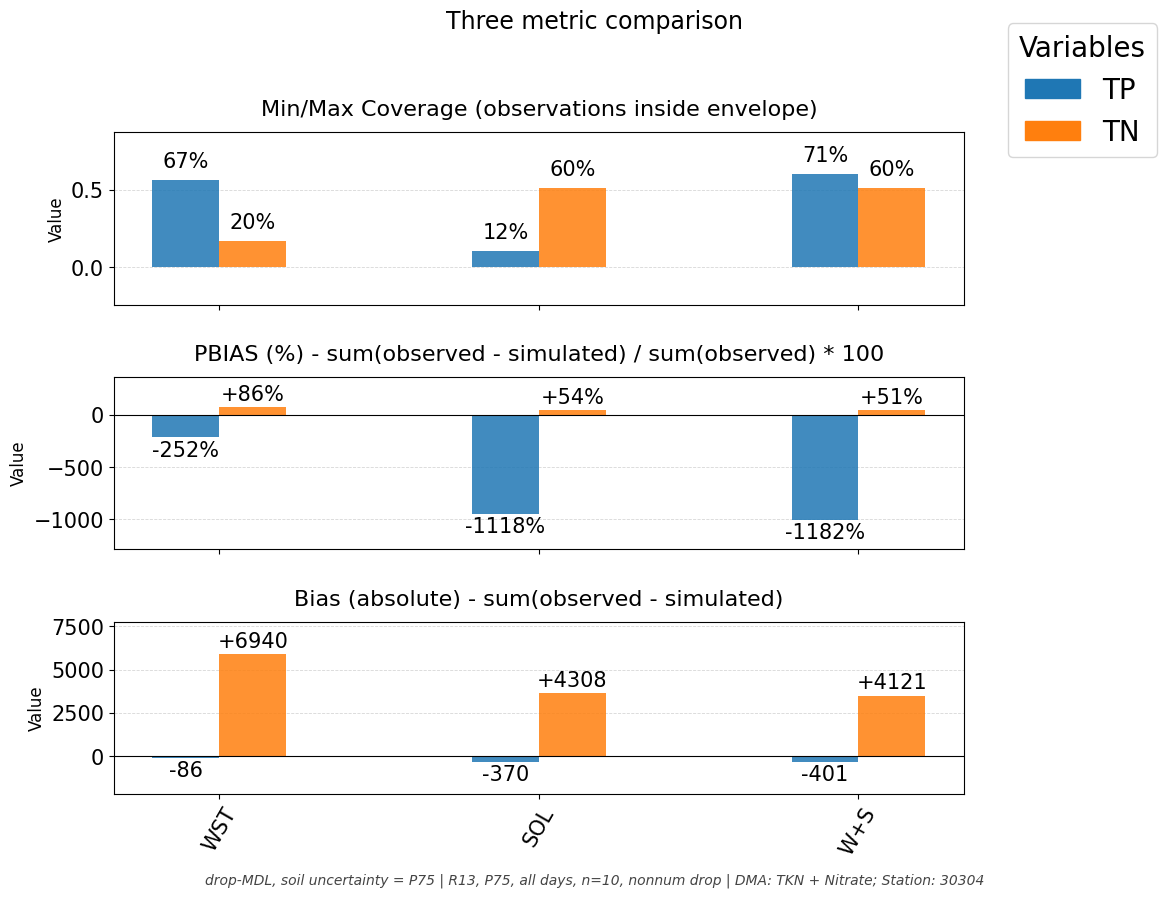

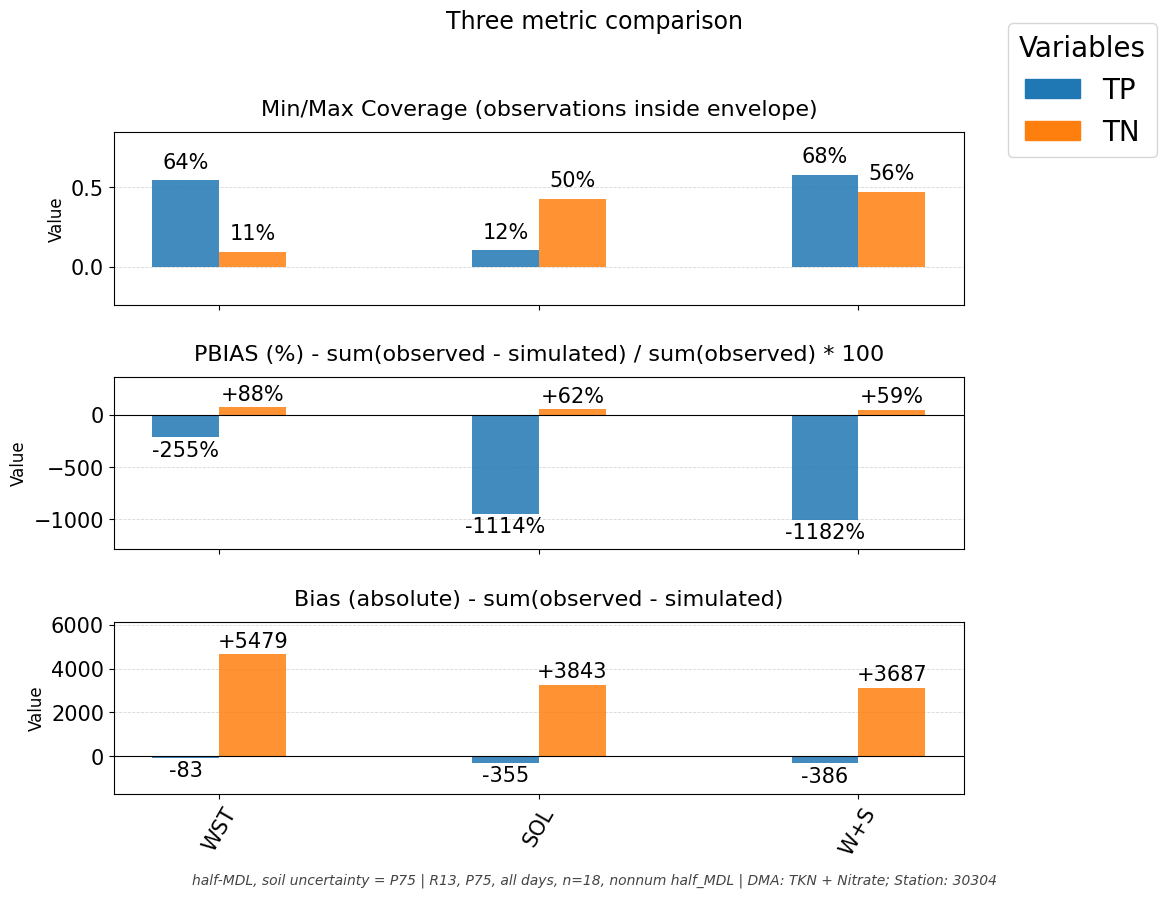

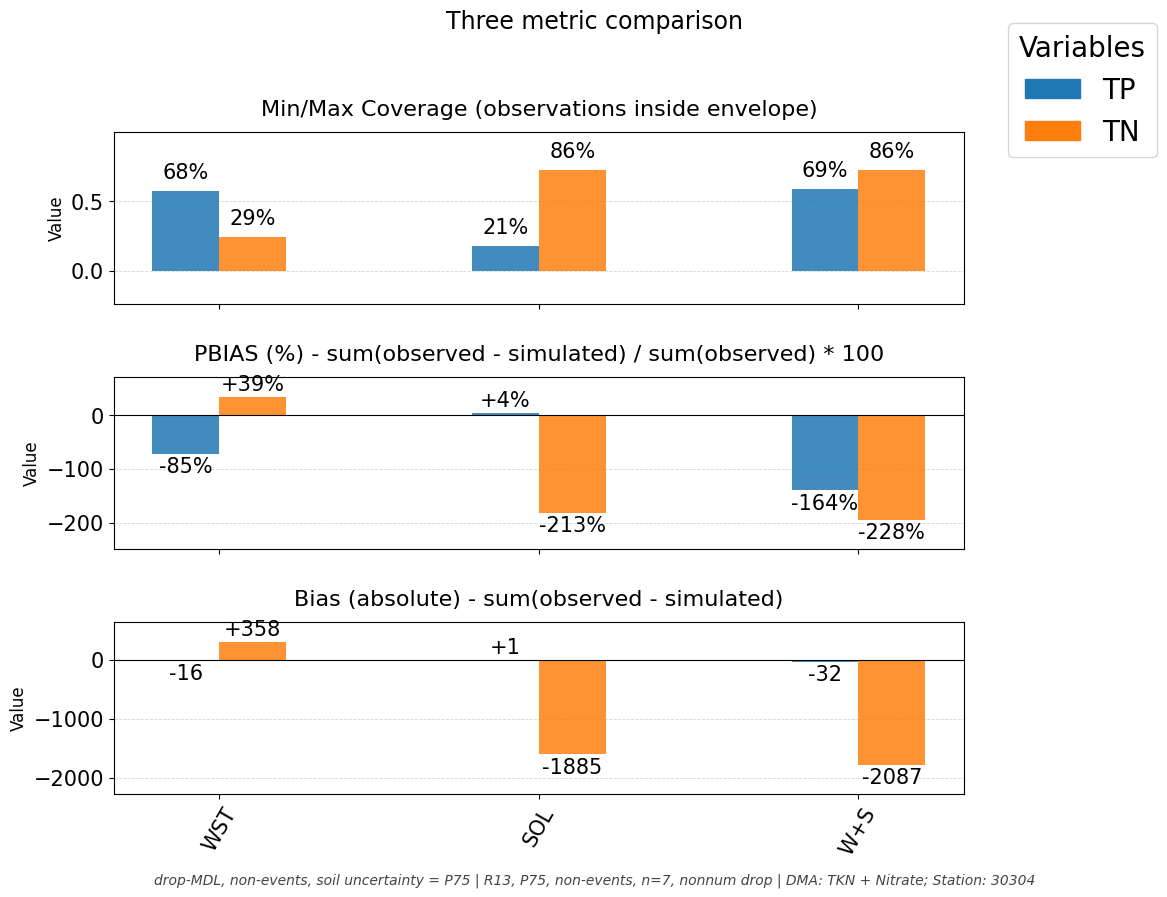

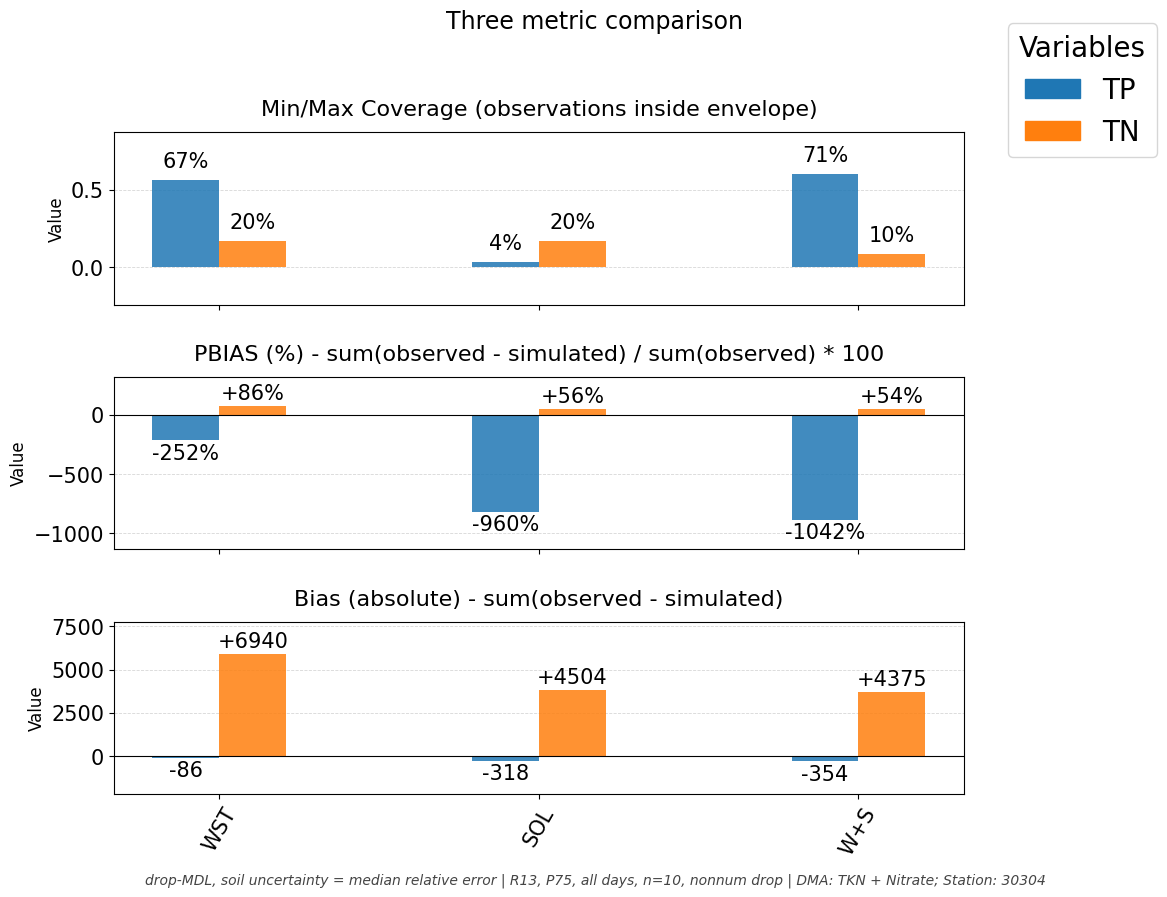

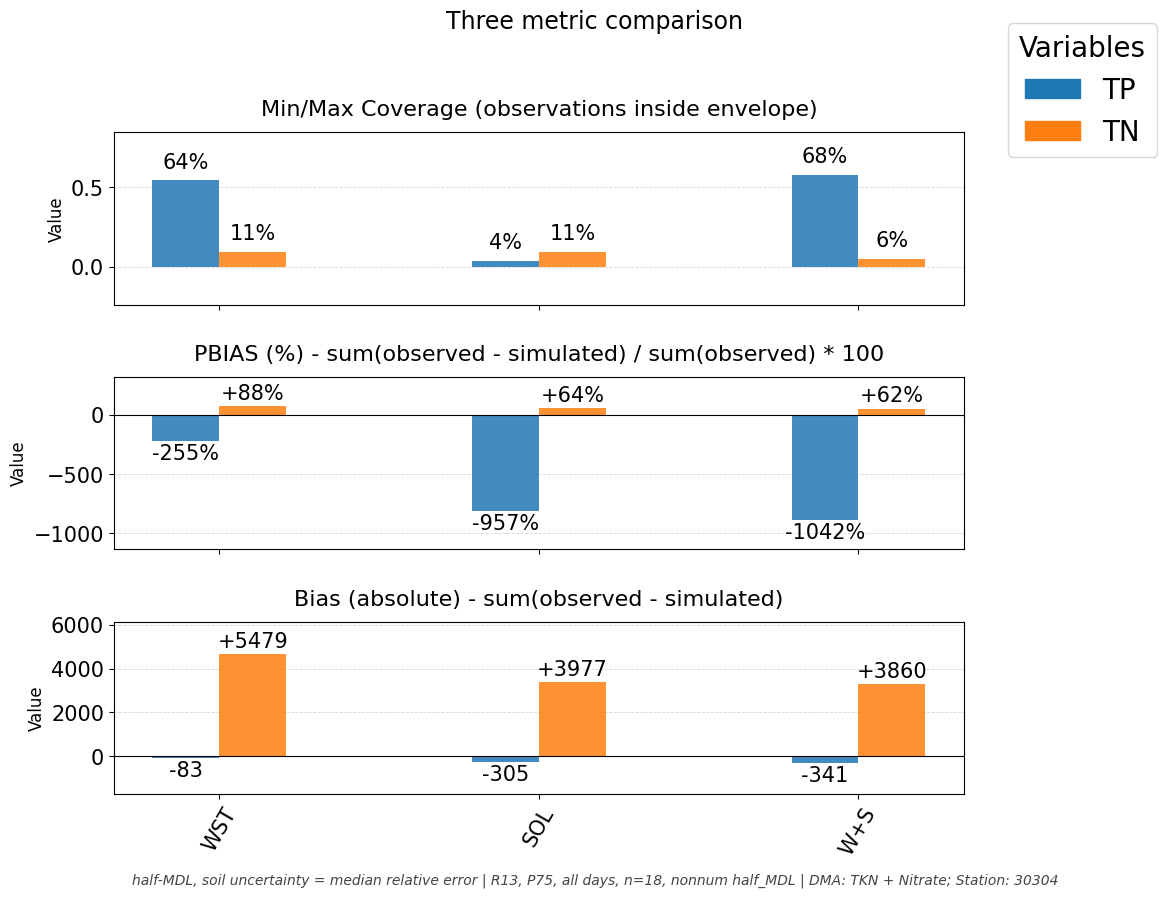

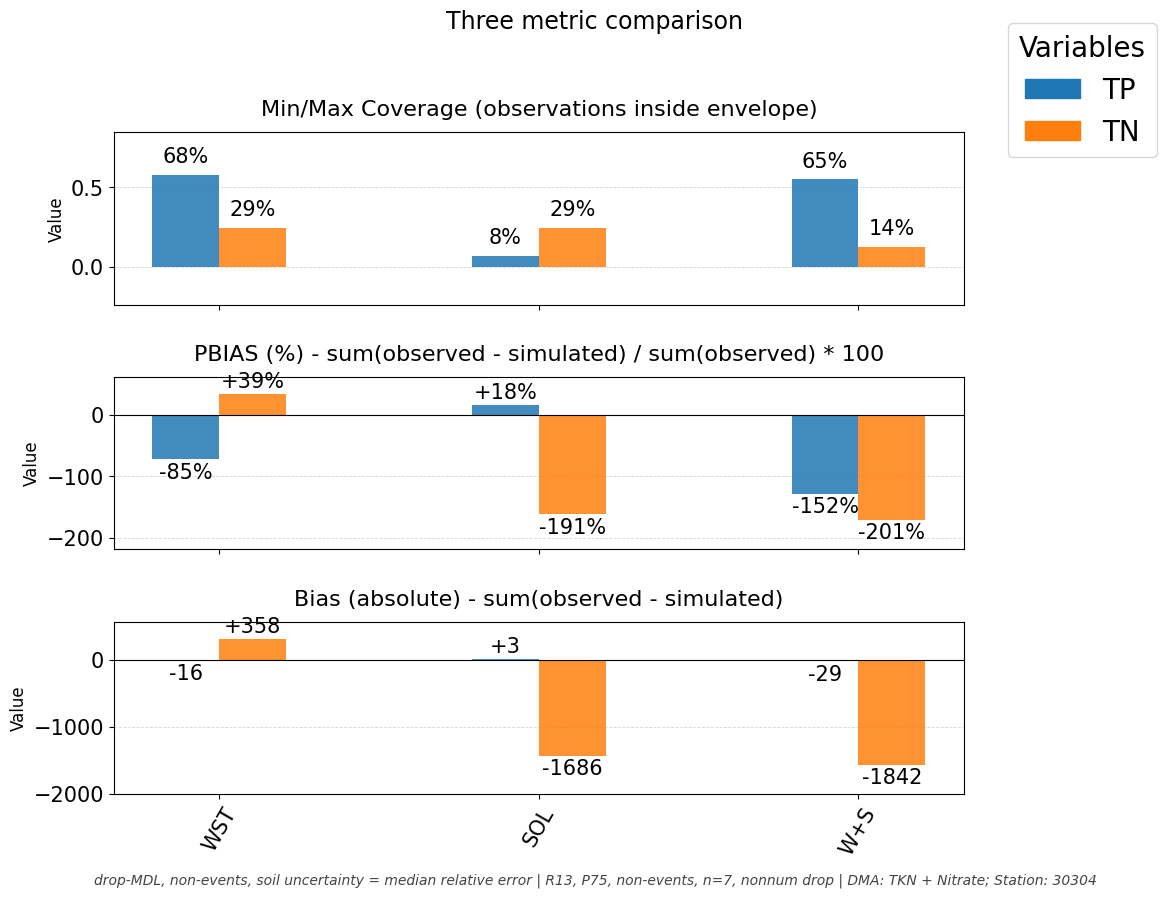

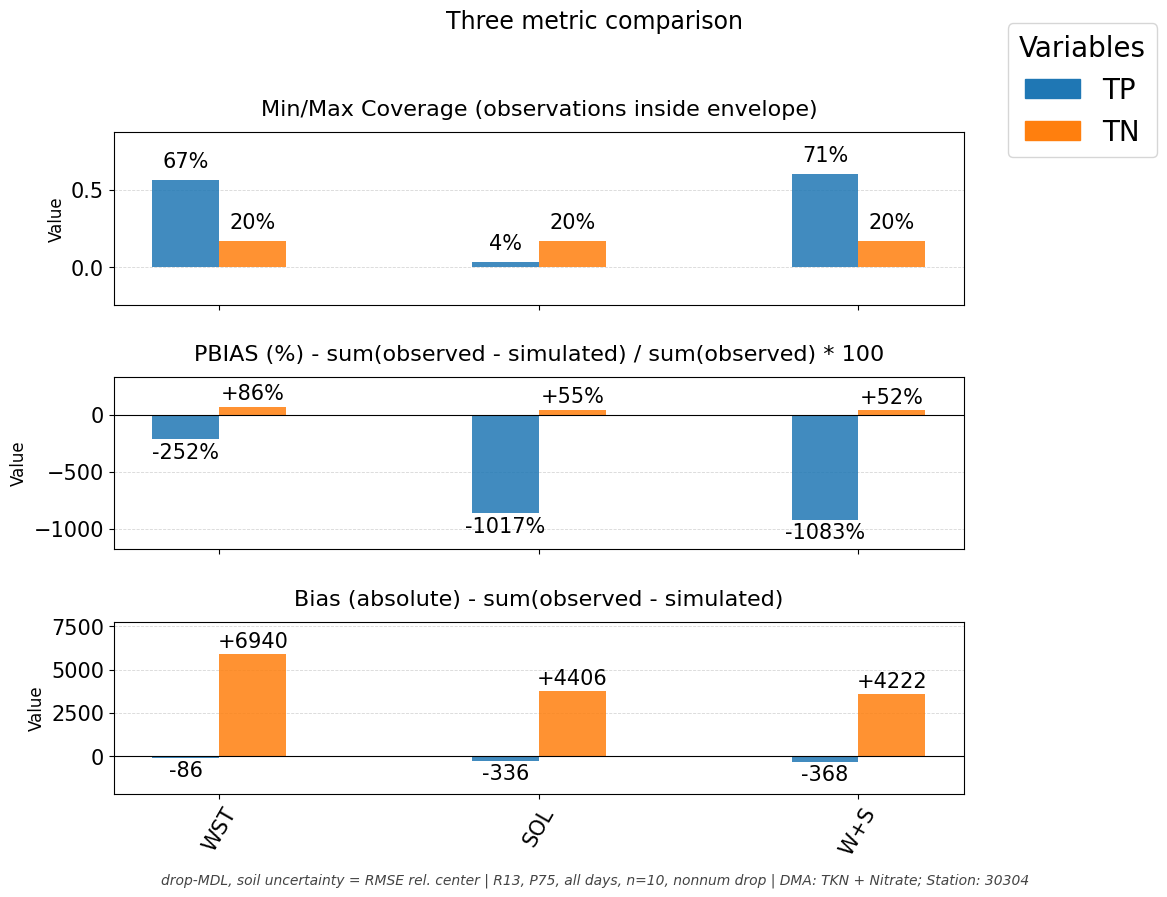

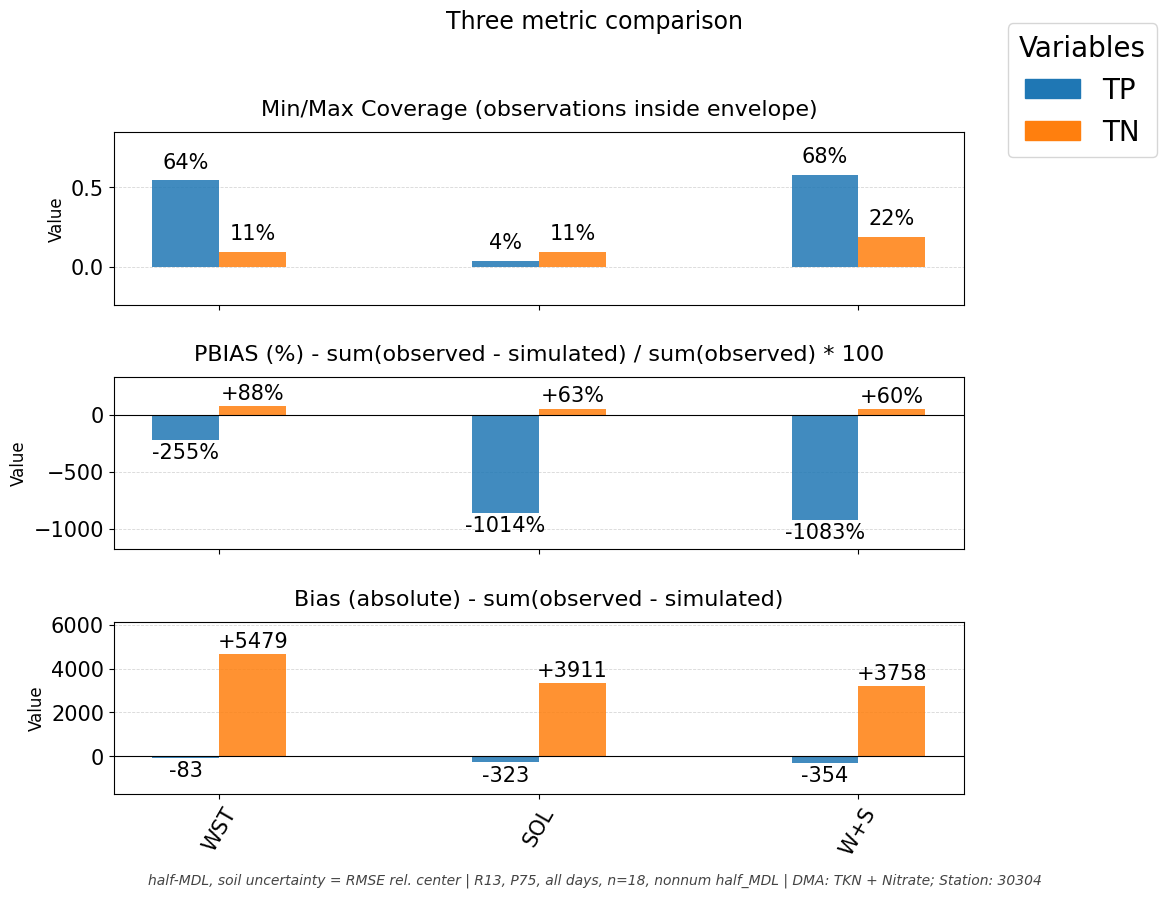

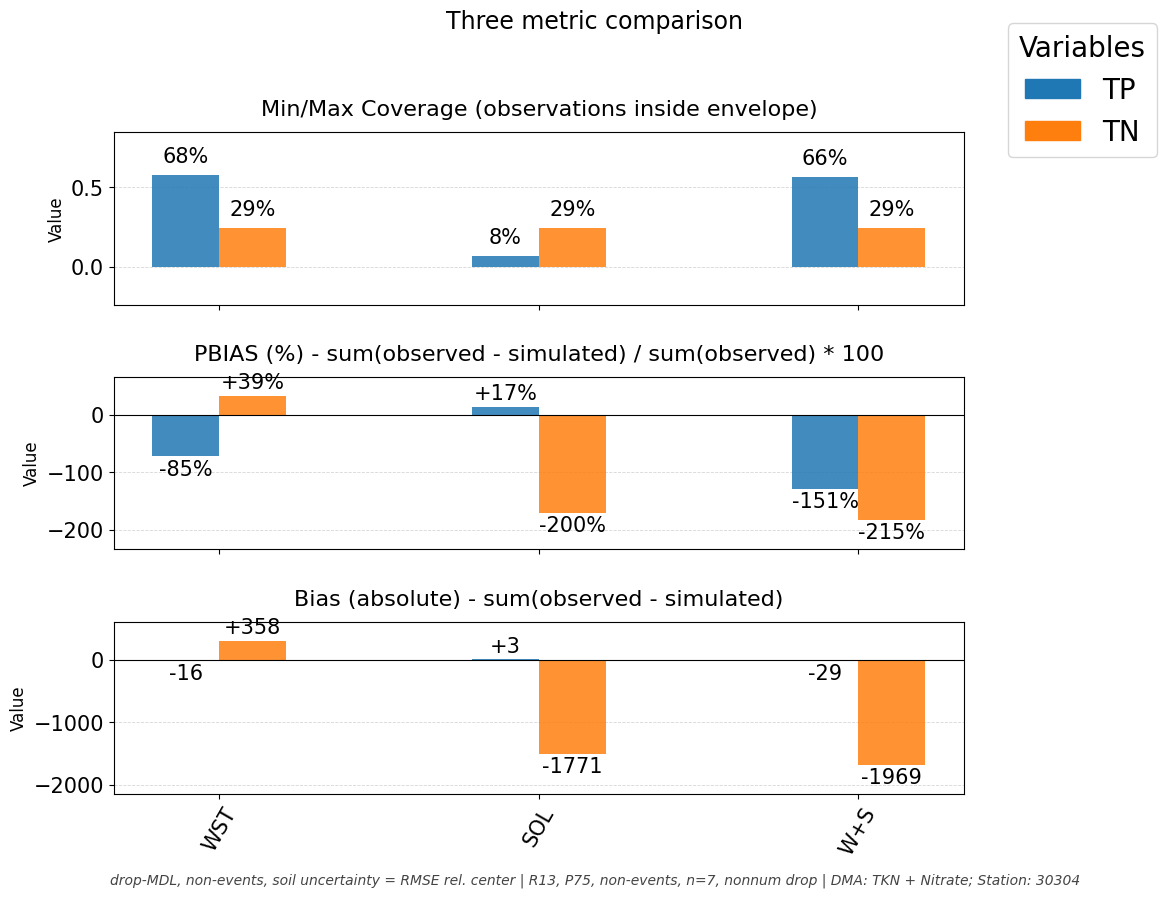

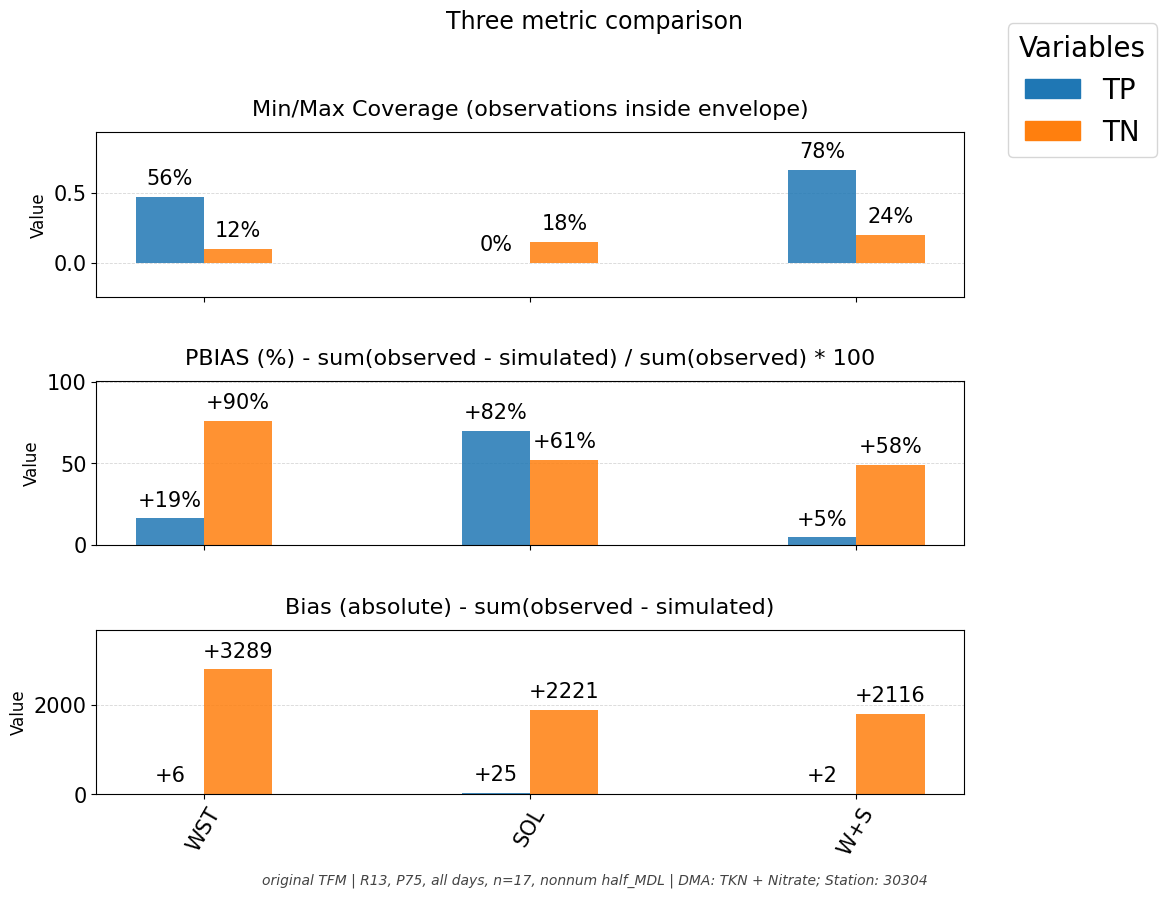


Finished chart 3 for all configured folders.
Chart 3 folder: runs_188_200_201__vars_tot_nkg_tot_pkg
  scenarios: ['WASTE', 'SOIL', 'WASTE+SOIL']
  variables: ['TP', 'TN']
Found 6 JSON files in C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\config\outputs\dashboard_stats\drop_mdl\runs_188_200_201__vars_tot_nkg_tot_pkg
  ✓ run-188: export_variable=tot-nkg, scenario=SOIL, variable=TN
  ✓ run-188: export_variable=tot-pkg, scenario=SOIL, variable=TP
  ✓ run-200: export_variable=tot-nkg, scenario=WASTE, variable=TN
  ✓ run-200: export_variable=tot-pkg, scenario=WASTE, variable=TP
  ✓ run-201: export_variable=tot-nkg, scenario=WASTE+SOIL, variable=TN
  ✓ run-201: export_variable=tot-pkg, scenario=WASTE+SOIL, variable=TP
  Note: no matched files were exported for runs: [153, 155, 157, 187, 189, 202, 203]

Built 6 export specs

Chart 3 folder: runs_188_200_201__vars_tot_nkg_tot_pkg
  scenarios: ['WASTE', 'SOIL', '

In [24]:
chart_3_metrics_by_folder = {}
chart_3_logs = []

for batch_folder in batch_folders:
    generated_specs, build_log = _capture_stdout(
        build_export_specs_from_folder,
        batch_folder,
        run_to_scenario,
        variable_map,
        verbose=True,
    )

    _ch3_actual_scenarios = list(dict.fromkeys(spec["scenario"] for spec in generated_specs))
    _ch3_actual_variables = list(dict.fromkeys(spec["variable"] for spec in generated_specs))
    _ch3_selected_scenarios = _ordered_present_values(_ch3_actual_scenarios, chart_scenario_order)
    _ch3_selected_variables = _ordered_present_values(_ch3_actual_variables, chart_variable_order)

    chart_title, chart_subtitle = build_semantic_chart_title(
        batch_folder, generated_specs,
        "Three metric comparison",
        title_metadata_parts=title_metadata_parts,
        title_folder_label_map=title_folder_label_map,
    )

    fig, ax, three_metric_stats = plot_three_metric_comparison(
        generated_specs,
        metric_specs=three_metric_specs,
        semantic_label_map=three_metric_semantic_label_map,
        variable_order=_ch3_selected_variables,
        scenario_order=_ch3_selected_scenarios,
        title=chart_title,
        subtitle=chart_subtitle,
        y_label="Value",
        figsize=(12, 9),
        abbreviations=chart_abbreviations,
        annotate_rotation=60,
        annot_fs=15,
        tick_fs=15,
        title_fs=16,
        label_fs=12,
        legend_fs=20,
        title_pad=12,
        subplot_h_pad=1.1,
        positive_bar_h_pad_scale=1.8,
        legend_outside=False,
        legend_loc="upper right",
        legend_bbox=(0.98, 0.98),
        tight_layout_rect=(0.0, 0.02, 0.82, 0.94),
        verbose=False,
    )
    plt.show()

    saved_path, save_log = _capture_stdout(
        _save_chart_figure,
        fig,
        batch_folder.name,
        "chart_3_three_metric",
        save_enabled=save_individual_chart_images,
        output_root=saved_chart_root,
        dpi=saved_chart_dpi,
    )
    plt.close(fig)

    chart_3_metrics_by_folder[batch_folder.name] = three_metric_stats
    chart_results_by_folder.setdefault(batch_folder.name, {})["chart_3_metrics"] = three_metric_stats
    chart_results_by_folder[batch_folder.name]["chart_3_saved_path"] = saved_path

    chart_3_logs.append(f"Chart 3 folder: {batch_folder.name}")
    chart_3_logs.append(f"  scenarios: {_ch3_selected_scenarios}")
    chart_3_logs.append(f"  variables: {_ch3_selected_variables}")
    if build_log.strip():
        chart_3_logs.append(build_log.rstrip())
    if save_log.strip():
        chart_3_logs.append(save_log.rstrip())
    chart_3_logs.append("")

print("\nFinished chart 3 for all configured folders.")
print("\n".join(line for line in chart_3_logs if line is not None))
